# 1. What is a Machine Learning Workflow?

A Machine Learning Workflow is the sequence of steps followed to build
a Machine Learning system.

A typical Machine Learning workflow looks like:

    Problem Definition
            ↓
    Data Collection
            ↓
    Data Understanding
            ↓
    Exploratory Data Analysis
            ↓
    Data Preprocessing
            ↓
    Feature Engineering
            ↓
    Train-Test Split
            ↓
    Model Selection
            ↓
    Model Training
            ↓
    Model Evaluation
            ↓
    Hyperparameter Tuning
            ↓
    Final Model
            ↓
    Model Saving
            ↓
    Deployment
            ↓
    Monitoring

Each step is important.

A good Machine Learning model cannot compensate for:

- Poor quality data
- Data leakage
- Incorrect preprocessing
- Wrong evaluation metrics
- Poor problem definition

In this notebook, we will follow this workflow using a
Customer Churn Prediction problem.

# 2. Problem Definition

The first step of a Machine Learning project is to clearly define
the problem.

Before writing any Machine Learning code, we should answer:

1. What problem are we trying to solve?
2. What is the input?
3. What should the model predict?
4. Is it a classification or regression problem?
5. How will we measure the model's performance?

## Problem Statement

A company wants to predict whether a customer will leave its service.

This is known as **Customer Churn Prediction**.

Our dataset contains information about customers such as:

- Region
- Signup date
- Subscription tier
- Number of orders
- Total amount spent

We will use this information to predict whether a customer has churned.

## Target Variable

The target variable is:

    churned

It contains two possible values:

- `False` → Customer did not churn
- `True` → Customer churned

Therefore, this is a **Binary Classification** problem.

## Machine Learning Objective

Our objective is:

    Customer Information
            ↓
    Machine Learning Model
            ↓
    Churn Prediction

# 3. Define the ML Problem Using the Dataset

Before building the model, we should identify the features and target.

## Features

Features are the input variables used by the Machine Learning model.

Potential features in our dataset include:

- `region`
- `signup_date`
- `subscription_tier`
- `orders_count`
- `total_spent_usd`

## Target

The target is the value that we want to predict:

    churned

## Columns That Should Not Be Used Directly

Some columns are not useful as predictive features.

For example:

- `customer_id` → Identifier, not meaningful customer behavior
- `name` → Personal identifier and not useful for this prediction

These columns should normally be removed before model training.

The `signup_date` column may contain useful information, but instead
of giving the raw date directly to most ML models, we can extract
useful features such as:

- Signup year
- Signup month
- Signup day
- Customer tenure

# 4. Data Collection

Data Collection is the process of obtaining the data required
to solve the Machine Learning problem.

Data can come from many sources, such as:

- Databases
- CSV files
- Excel files
- APIs
- Websites
- Sensors
- Applications
- Company internal systems

The quality of the collected data has a major impact on the
performance of the final Machine Learning model.

For this notebook, our customer data is provided directly as
a Python dictionary and converted into a pandas DataFrame.

In a real-world project, this data could come from a database
or a CSV file.

In [ ]:
# Import pandas
import pandas as pd

# Create the customer churn dataset
data = {
    "customer_id": list(range(101, 151)),

    "name": [
        "Sarah Jenkins", "Marcus Chen", "Elena Rostova", "Devon Vance", "Aisha Patel",
        "Liam O'Connor", "Sofia Reyes", "Kenji Sato", "Maya Lin", "Lucas Becker",
        "Amara Okafor", "Mateo Silva", "Chloe Dubois", "Noah Kim", "Zara Al-Mansoor",
        "Ethan Wright", "Fatima Zahra", "Oliver Hansen", "Priya Sharma", "Gabriel Santos",
        "Hannah Schmidt", "Julian Rossi", "Ananya Iyer", "Dominic Cruz", "Leila Haddad",
        "Sebastian Meyer", "Nia Johnson", "Kaito Tanaka", "Camila Fernandez", "Owen Davis",
        "Ingrid Larsen", "Tariq Mansour", "Freja Nielsen", "Rohan Mehta", "Valeria Gomez",
        "Felix Laurent", "Zoe Mitchell", "Dante Moretti", "Yuki Takahashi", "Harper Clark",
        "Karim Benzema", "Siddharth Nair", "Elise Fontaine", "Leonidas Thorne", "Amina Diallo",
        "Jonas Lindqvist", "Beatriz Costa", "Arjun Kapoor", "Mei-Ling Wang", "Callum Scott",
    ],

    "region": [
        "North", "West", "East", "South", "West",
        "North", "South", "East", "West", "North",
        "South", "East", "North", "West", "South",
        "East", "North", "West", "South", "East",
        "North", "South", "West", "East", "North",
        "South", "West", "East", "North", "South",
        "East", "West", "North", "South", "West",
        "East", "North", "South", "East", "West",
        "North", "South", "East", "West", "North",
        "South", "East", "North", "West", "South",
    ],

    "signup_date": pd.to_datetime([
        "2026-01-14", "2026-02-03", "2026-03-21", "2025-11-19", "2026-04-05",
        "2025-12-30", "2026-05-12", "2026-02-18", "2026-03-10", "2026-06-01",
        "2025-10-15", "2026-04-22", "2026-01-29", "2025-11-04", "2026-05-30",
        "2026-02-11", "2025-09-18", "2026-03-05", "2025-12-14", "2026-04-18",
        "2026-01-08", "2025-10-29", "2026-05-02", "2026-02-24", "2025-11-30",
        "2026-03-15", "2026-01-22", "2025-12-05", "2026-04-28", "2026-06-10",
        "2025-10-02", "2026-02-14", "2026-03-30", "2025-11-12", "2026-05-19",
        "2026-01-19", "2026-04-09", "2025-12-22", "2026-03-01", "2026-05-25",
        "2025-10-20", "2026-02-27", "2026-04-14", "2025-11-08", "2026-06-05",
        "2026-01-03", "2026-03-18", "2025-12-11", "2026-04-30", "2026-02-07",
    ]),

    "subscription_tier": [
        "Premium", "Free", "Free", "Enterprise", "Premium",
        "Free", "Enterprise", "Premium", "Free", "Premium",
        "Enterprise", "Free", "Free", "Enterprise", "Premium",
        "Free", "Enterprise", "Premium", "Free", "Enterprise",
        "Free", "Premium", "Free", "Enterprise", "Free",
        "Premium", "Free", "Enterprise", "Premium", "Free",
        "Enterprise", "Premium", "Free", "Enterprise", "Free",
        "Premium", "Free", "Enterprise", "Premium", "Free",
        "Enterprise", "Premium", "Free", "Enterprise", "Free",
        "Premium", "Free", "Enterprise", "Premium", "Free",
    ],

    "orders_count": [
        12, 3, 0, 45, 18,
        5, 29, 14, 0, 8,
        52, 2, 0, 38, 16,
        1, 61, 21, 0, 44,
        4, 15, 0, 39, 2,
        22, 0, 50, 19, 3,
        48, 11, 0, 57, 1,
        25, 0, 41, 13, 2,
        64, 17, 0, 46, 3,
        20, 0, 53, 15, 4,
    ],

    "total_spent_usd": [
        429.50, 89.99, 0.00, 1240.25, 612.00,
        135.40, 890.75, 495.10, 0.00, 280.60,
        1590.40, 45.00, 0.00, 1120.00, 540.25,
        19.99, 1820.50, 710.00, 0.00, 1345.80,
        98.50, 480.20, 0.00, 1190.00, 42.10,
        745.60, 0.00, 1480.90, 625.30, 74.50,
        1410.75, 360.00, 0.00, 1730.20, 24.99,
        820.15, 0.00, 1260.40, 430.80, 55.00,
        1950.00, 560.70, 0.00, 1380.50, 68.20,
        690.40, 0.00, 1620.10, 510.90, 88.00,
    ],

    "churned": [
        False, False, True, False, False,
        True, False, False, True, False,
        False, False, True, False, False,
        False, False, False, True, False,
        False, False, True, False, True,
        False, True, False, False, False,
        False, False, True, False, True,
        False, True, False, False, False,
        False, False, True, False, True,
        False, True, False, False, False,
    ],
}

# Convert the dictionary into a DataFrame
df = pd.DataFrame(data)

# Display the dataset
df

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,0,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45,1240.25,False
4,105,Aisha Patel,West,2026-04-05,Premium,18,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5,135.40,True
6,107,Sofia Reyes,South,2026-05-12,Enterprise,29,890.75,False
7,108,Kenji Sato,East,2026-02-18,Premium,14,495.10,False
8,109,Maya Lin,West,2026-03-10,Free,0,0.00,True
9,110,Lucas Becker,North,2026-06-01,Premium,8,280.60,False


# 5. Data Understanding

After collecting the data, the next step is to understand
what the dataset contains.

We should identify:

- Number of rows
- Number of columns
- Feature names
- Data types
- Numerical features
- Categorical features
- Target variable

This step gives us a basic understanding of the data before
performing detailed Exploratory Data Analysis.

In [297]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 50
Number of columns: 8


In [298]:
# Display all column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['customer_id', 'name', 'region', 'signup_date', 'subscription_tier', 'orders_count', 'total_spent_usd', 'churned']


In [299]:
# Display all column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['customer_id', 'name', 'region', 'signup_date', 'subscription_tier', 'orders_count', 'total_spent_usd', 'churned']


# 6. Identify Feature Types

Machine Learning datasets usually contain different types of
features.

## Numerical Features

Numerical features contain numbers.

In our dataset:

- `orders_count`
- `total_spent_usd`

## Categorical Features

Categorical features contain groups or categories.

In our dataset:

- `region`
- `subscription_tier`

## Date Feature

Our dataset contains:

- `signup_date`

Dates can contain useful information, but raw dates are usually
transformed into meaningful numerical features.

## Identifier Columns

Our dataset also contains:

- `customer_id`
- `name`

These are identifiers and should generally not be used directly
as predictive features.

In [300]:
# Define the different types of columns

numerical_features = [
    "orders_count",
    "total_spent_usd"
]

categorical_features = [
    "region",
    "subscription_tier"
]

date_features = [
    "signup_date"
]

identifier_features = [
    "customer_id",
    "name"
]

target = "churned"

# Display the groups
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("Date Features:", date_features)
print("Identifier Features:", identifier_features)
print("Target:", target)

Numerical Features: ['orders_count', 'total_spent_usd']
Categorical Features: ['region', 'subscription_tier']
Date Features: ['signup_date']
Identifier Features: ['customer_id', 'name']
Target: churned


# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is the process of examining the dataset
to discover patterns, problems, and relationships.

EDA helps us answer questions such as:

- Are there missing values?
- Are there duplicate records?
- What is the distribution of numerical features?
- What categories exist?
- How is the target distributed?
- Are there outliers?
- Which features may be related to the target?

EDA should be performed before building the Machine Learning model.

The goal is not simply to create charts.

The goal is to understand the data and make better decisions
about preprocessing and model development.

## 8. Dataset Shape

The `shape` attribute returns the dimensions of the DataFrame.

It returns:

    (number of rows, number of columns)

In our dataset:

- Each row represents a customer.
- Each column represents a feature or variable.

In [301]:
# Check the shape of the dataset
df.shape

(50, 8)

## 9. Viewing the Dataset

Before analyzing the dataset, we should inspect the actual
records.

Pandas provides:

- `head()` → First rows
- `tail()` → Last rows
- `sample()` → Random rows

These functions provide a quick overview of the data.

In [302]:
# Display the first 5 rows
df.head()

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,0,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45,1240.25,False
4,105,Aisha Patel,West,2026-04-05,Premium,18,612.00,False


In [303]:
# Display the last 5 rows
df.tail()

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
45,146,Jonas Lindqvist,South,2026-01-03,Premium,20,690.4,False
46,147,Beatriz Costa,East,2026-03-18,Free,0,0.0,True
47,148,Arjun Kapoor,North,2025-12-11,Enterprise,53,1620.1,False
48,149,Mei-Ling Wang,West,2026-04-30,Premium,15,510.9,False
49,150,Callum Scott,South,2026-02-07,Free,4,88.0,False


In [304]:
# Display 3 random rows
df.sample(3)

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
10,111,Amara Okafor,South,2025-10-15,Enterprise,52,1590.4,False
21,122,Julian Rossi,South,2025-10-29,Premium,15,480.2,False
49,150,Callum Scott,South,2026-02-07,Free,4,88.0,False


## 10.1 Missing Values

Missing values occur when information is unavailable for
one or more observations.

Missing data can cause problems during model training.

Common techniques for handling missing values include:

- Removing rows
- Removing columns
- Filling with mean
- Filling with median
- Filling with mode
- Advanced imputation

We should first identify missing values before deciding
how to handle them.

In [305]:
# Count missing values in each column
df.isnull().sum()

customer_id          0
name                 0
region               0
signup_date          0
subscription_tier    0
orders_count         0
total_spent_usd      0
churned              0
dtype: int64

In [306]:
# Check whether any missing value exists
df.isnull().any().any()

np.False_

## 10.2 Duplicate Records

Duplicate records are rows that appear more than once.

Duplicates can affect model training because the same observation
may receive more importance than it should.

Therefore, we should identify duplicate rows before continuing
with the Machine Learning workflow.

In [307]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [308]:
# Display duplicate rows
df[df.duplicated()]

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned


## 10.3 Statistical Summary

Statistical summaries help us understand numerical features.

The `describe()` method provides:

- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median
- 75th percentile
- Maximum

This gives us a quick understanding of the range and distribution
of numerical variables.

In [309]:
# Generate statistical summary for numerical features
df[numerical_features].describe()

,orders_count,total_spent_usd
count,50.000000,50.00000
mean,18.860000,581.27440
std,19.991845,603.04645
min,0.000000,0.00000
25%,2.000000,42.82500
50%,13.500000,455.50000
75%,35.750000,1062.68750
max,64.000000,1950.00000


## 10.4 Categorical Feature Analysis

Categorical features contain a fixed number of categories.

For our dataset, the main categorical features are:

- `region`
- `subscription_tier`

We can use `unique()` to find the available categories and
`value_counts()` to count how frequently each category occurs.

In [310]:
# Display unique regions
df["region"].unique()

<StringArray>
['North', 'West', 'East', 'South']
Length: 4, dtype: str

In [311]:
# Count customers in each region
df["region"].value_counts()

region
North    13
South    13
West     12
East     12
Name: count, dtype: int64

In [312]:
# Display unique subscription tiers
df["subscription_tier"].unique()

<StringArray>
['Premium', 'Free', 'Enterprise']
Length: 3, dtype: str

In [313]:
# Count customers in each subscription tier
df["subscription_tier"].value_counts()

subscription_tier
Free          21
Premium       15
Enterprise    14
Name: count, dtype: int64

## 10.5 Target Variable Analysis

The target variable is the variable that the Machine Learning
model is expected to predict.

For our problem:

    Target = churned

The target has two classes:

- `False` → Customer did not churn
- `True` → Customer churned

Because there are two classes, this is a binary classification problem.

We should check the distribution of these two classes before
training the model.

In [314]:
# Count the number of customers in each target class
df["churned"].value_counts()

churned
False    36
True     14
Name: count, dtype: int64

In [315]:
# Calculate the churn rate
churn_rate = df["churned"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 28.00%


## 10.6 Target Distribution

Visualization helps us understand the distribution of the target.

A bar chart can show how many customers:

- Churned
- Did not churn

This is particularly important when checking for class imbalance.

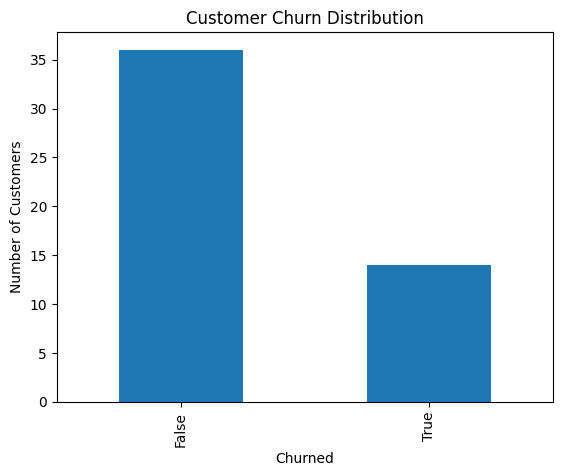

In [316]:
# Import matplotlib
import matplotlib.pyplot as plt

# Count target classes
churn_counts = df["churned"].value_counts()

# Create a bar chart
churn_counts.plot(kind="bar")

# Add labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

plt.show()

## 10.7 EDA Observation

From the initial EDA, we can now understand:

- The size of the dataset
- The available features
- The data types
- Whether missing values exist
- Whether duplicate records exist
- The distribution of numerical variables
- The distribution of categorical variables
- The distribution of the target variable

EDA gives us the information required for the next stage
of the workflow.

The next step is:

    Data Understanding
            ↓
          EDA
            ↓
    Data Preprocessing
            ↓
    Feature Engineering

# 11. Data Preprocessing

Data Preprocessing is the process of cleaning and transforming
raw data into a format that can be used by Machine Learning
algorithms.

Real-world datasets may contain:

- Missing values
- Duplicate records
- Irrelevant features
- Categorical values
- Date values
- Different numerical scales
- Incorrect data types

The main goal of preprocessing is to make the data
clean, consistent, and suitable for Machine Learning.

The preprocessing workflow is:

    Raw Data
        ↓
    Separate Features and Target
        ↓
    Remove Irrelevant Features
        ↓
    Handle Missing Values
        ↓
    Handle Duplicates
        ↓
    Transform Date Features
        ↓
    Encode Categorical Features
        ↓
    Scale Numerical Features
        ↓
    Preprocessed Data

## 11.1 Separating Features and Target

Before preprocessing, we separate the dataset into two parts:

### Features (X)

Features are the input variables used by the Machine Learning
model to make predictions.

For our customer churn problem, examples include:

- region
- signup_date
- subscription_tier
- orders_count
- total_spent_usd

### Target (y)

The target is the variable that we want the model to predict.

In our dataset:

    Target = churned

Therefore:

    X → Input features
    y → Target variable

The target should be kept separate from the input features.

In [317]:
# Separate features from the target variable

X = df.drop("churned", axis=1)

# Store the target variable separately
y = df["churned"]

# Display the features
X.head()

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd
0,101,Sarah Jenkins,North,2026-01-14,Premium,12,429.50
1,102,Marcus Chen,West,2026-02-03,Free,3,89.99
2,103,Elena Rostova,East,2026-03-21,Free,0,0.00
3,104,Devon Vance,South,2025-11-19,Enterprise,45,1240.25
4,105,Aisha Patel,West,2026-04-05,Premium,18,612.00


## 11.2 Removing Irrelevant Features

Not every column in a dataset is useful for prediction.

Our dataset contains:

- `customer_id`
- `name`

These columns are identifiers rather than meaningful
customer behavior.

### customer_id

The customer ID is simply an identifier.

For example:

    101, 102, 103, ...

The numerical value does not represent customer behavior.

### name

The customer's name is also not useful for predicting churn.

Therefore, these columns should be removed before
training the Machine Learning model.

Removing irrelevant features can:

- Reduce unnecessary information
- Simplify the dataset
- Reduce noise
- Make the model easier to understand

In [318]:
# Remove identifier columns

X = X.drop(
    ["customer_id", "name"],
    axis=1
)

# Display the remaining features
X.head()

,region,signup_date,subscription_tier,orders_count,total_spent_usd
0,North,2026-01-14,Premium,12,429.50
1,West,2026-02-03,Free,3,89.99
2,East,2026-03-21,Free,0,0.00
3,South,2025-11-19,Enterprise,45,1240.25
4,West,2026-04-05,Premium,18,612.00


## 11.3 Checking Missing Values

Missing values occur when information is not available for
one or more observations.

In a real-world dataset, missing values are very common.

For example, a customer may have:

- Missing region
- Missing subscription tier
- Missing number of orders
- Missing spending information

Missing values are usually represented as `NaN` in pandas.

Machine Learning algorithms may not be able to work directly
with missing values.

Therefore, we need to:

1. Detect missing values
2. Understand where they occur
3. Decide how to handle them

Common methods for handling missing values include:

- Removing rows
- Removing columns
- Filling numerical values with mean
- Filling numerical values with median
- Filling categorical values with mode
- Using advanced imputation techniques

In [319]:
# Create a copy of the original dataset
# We keep the original df unchanged
import numpy as np
df_ml = df.copy()

# Add some missing values intentionally for practice

# Missing numerical value
df_ml.loc[2, "orders_count"] = np.nan

# Missing numerical value
df_ml.loc[5, "total_spent_usd"] = np.nan

# Missing categorical value
df_ml.loc[4, "region"] = np.nan

# Missing categorical value
df_ml.loc[6, "subscription_tier"] = np.nan

# Display the modified dataset
df_ml

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12.0,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3.0,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,NaN,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45.0,1240.25,False
4,105,Aisha Patel,NaN,2026-04-05,Premium,18.0,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5.0,NaN,True
6,107,Sofia Reyes,South,2026-05-12,NaN,29.0,890.75,False
7,108,Kenji Sato,East,2026-02-18,Premium,14.0,495.10,False
8,109,Maya Lin,West,2026-03-10,Free,0.0,0.00,True
9,110,Lucas Becker,North,2026-06-01,Premium,8.0,280.60,False


In [320]:
# Count missing values in every column

df_ml.isnull().sum()

customer_id          0
name                 0
region               1
signup_date          0
subscription_tier    1
orders_count         1
total_spent_usd      1
churned              0
dtype: int64

In [321]:
# Find rows that contain at least one missing value

df_ml[df_ml.isnull().any(axis=1)]

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
2,103,Elena Rostova,East,2026-03-21,Free,NaN,0.00,True
4,105,Aisha Patel,NaN,2026-04-05,Premium,18.0,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5.0,NaN,True
6,107,Sofia Reyes,South,2026-05-12,NaN,29.0,890.75,False


### Checking Missing Value Percentage

The number of missing values alone may not be enough.

For a large dataset, it is useful to calculate the percentage
of missing values in each column.

Formula:

    Missing Percentage
    = (Missing Values / Total Values) × 100

In [322]:
# Calculate missing value percentage

missing_percentage = (
    df_ml.isnull().mean() * 100
)

missing_percentage

customer_id          0.0
name                 0.0
region               2.0
signup_date          0.0
subscription_tier    2.0
orders_count         2.0
total_spent_usd      2.0
churned              0.0
dtype: float64

## 11.4 Handling Missing Values

After detecting missing values, we need to decide how
to handle them.

The method depends on the type of feature.

### Numerical Features

For numerical features, common methods are:

- Mean
- Median

The median is often preferred when the data contains
outliers because it is less affected by extreme values.

### Categorical Features

For categorical features, we can use:

- Mode
- A new category such as `"Unknown"`

For this dataset, we will use:

- Median for numerical features
- Mode for categorical features

This allows us to keep all customer records instead
of deleting rows.    

In [323]:
# Check missing values in numerical columns

numerical_features = [
    "orders_count",
    "total_spent_usd"
]

df_ml[numerical_features].isnull().sum()

orders_count       1
total_spent_usd    1
dtype: int64

In [324]:
# Fill missing numerical values with the median

for column in numerical_features:
    df_ml[column] = df_ml[column].fillna(
        df_ml[column].median()
    )

# Check again
df_ml[numerical_features].isnull().sum()

orders_count       0
total_spent_usd    0
dtype: int64

### Why Median?

Suppose a feature contains:

    10, 12, 15, 18, 1000

The value `1000` is much larger than the other values.

The mean will be strongly affected by this extreme value,
while the median will remain more representative of the
typical observation.

Therefore, median imputation can be useful when numerical
data contains potential outliers.

In [325]:
# Check missing values in categorical columns

categorical_features = [
    "region",
    "subscription_tier"
]

df_ml[categorical_features].isnull().sum()

region               1
subscription_tier    1
dtype: int64

In [326]:
# Fill missing categorical values using the mode

for column in categorical_features:
    df_ml[column] = df_ml[column].fillna(
        df_ml[column].mode()[0]
    )

# Check again
df_ml[categorical_features].isnull().sum()

region               0
subscription_tier    0
dtype: int64

In [327]:
# Check all missing values after imputation

df_ml.isnull().sum()

customer_id          0
name                 0
region               0
signup_date          0
subscription_tier    0
orders_count         0
total_spent_usd      0
churned              0
dtype: int64

## 11.5 Checking Duplicate Records

A duplicate record is a row that contains the same information
as another row.

Duplicate records can create problems because the same
observation may be given extra importance during model training.

For example, if the same customer appears multiple times,
the Machine Learning model may treat those records as
different observations.

Therefore, duplicate records should be identified before
training the model.

In [328]:
# Create a duplicate record intentionally for practice

# Select one existing row
duplicate_row = df_ml.iloc[[1]]

# Add the duplicate row to the dataset
df_ml = pd.concat(
    [df_ml, duplicate_row],
    ignore_index=True
)

# Display the dataset
df_ml

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12.0,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3.0,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,14.0,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45.0,1240.25,False
4,105,Aisha Patel,North,2026-04-05,Premium,18.0,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5.0,480.20,True
6,107,Sofia Reyes,South,2026-05-12,Free,29.0,890.75,False
7,108,Kenji Sato,East,2026-02-18,Premium,14.0,495.10,False
8,109,Maya Lin,West,2026-03-10,Free,0.0,0.00,True
9,110,Lucas Becker,North,2026-06-01,Premium,8.0,280.60,False


In [329]:
# Count duplicate rows

df_ml.duplicated().sum()

np.int64(1)

### Understanding `duplicated()`

The `duplicated()` method checks whether a row has already
appeared earlier in the dataset.

It returns:

- `True` → Duplicate row
- `False` → Unique row

Using:

    df_ml.duplicated().sum()

gives us the total number of duplicate rows.

In [330]:
# Display all duplicate rows

df_ml[df_ml.duplicated()]

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
50,102,Marcus Chen,West,2026-02-03,Free,3.0,89.99,False


## 11.6 Removing Duplicate Records

Once duplicate records have been identified, we can remove them.

Pandas provides the `drop_duplicates()` method for this purpose.

By default, pandas keeps the first occurrence and removes
the subsequent duplicate records.

Therefore:

    Before removing duplicates → 9 rows

    After removing duplicates → 8 rows

In [331]:
# Remove duplicate records

df_ml = df_ml.drop_duplicates()

# Check the new shape
df_ml.shape

(50, 8)

In [332]:
# Verify that no duplicate rows remain

df_ml.duplicated().sum()

np.int64(0)

## 11.7 Verifying the Cleaned Dataset

After handling missing values and duplicate records,
we should verify that the dataset is clean.

We will check:

- Dataset shape
- Missing values
- Duplicate records
- Data types

This is an important habit in Machine Learning workflows.

After every major preprocessing operation, verify the result
instead of assuming that the operation worked correctly.

In [333]:
# Check the final shape

print("Dataset Shape:", df_ml.shape)

Dataset Shape: (50, 8)


In [334]:
# Check remaining missing values

print("Missing Values:")
print(df_ml.isnull().sum())

Missing Values:
customer_id          0
name                 0
region               0
signup_date          0
subscription_tier    0
orders_count         0
total_spent_usd      0
churned              0
dtype: int64


In [335]:
# Check data types

df_ml.dtypes

customer_id                   int64
name                            str
region                          str
signup_date          datetime64[us]
subscription_tier               str
orders_count                float64
total_spent_usd             float64
churned                        bool
dtype: object

## 11.8 Data Preprocessing Observation

We intentionally introduced missing values and a duplicate
record into the dataset to understand how they are handled.

We then:

- Detected missing values
- Calculated missing-value percentages
- Filled numerical missing values using the median
- Filled categorical missing values using the mode
- Detected duplicate records
- Removed duplicate records
- Verified the cleaned dataset

The dataset is now ready for the next preprocessing step.

The next step is:

    Date Feature Engineering

In [336]:
# Display the cleaned dataset

df_ml

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12.0,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3.0,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,14.0,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45.0,1240.25,False
4,105,Aisha Patel,North,2026-04-05,Premium,18.0,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5.0,480.20,True
6,107,Sofia Reyes,South,2026-05-12,Free,29.0,890.75,False
7,108,Kenji Sato,East,2026-02-18,Premium,14.0,495.10,False
8,109,Maya Lin,West,2026-03-10,Free,0.0,0.00,True
9,110,Lucas Becker,North,2026-06-01,Premium,8.0,280.60,False


## 11.9 Date Feature Engineering

Machine Learning algorithms generally work with numerical
features rather than raw date values.

For example:

    2026-01-14

is a date, but it can contain several useful pieces of
information such as:

- Year
- Month
- Day
- Day of week
- Customer tenure

Therefore, instead of directly using the raw `signup_date`,
we can extract useful information from it.

This process is called **Date Feature Engineering**.

For our customer churn problem, the date can help us
understand how long a customer has been associated with
the company.

In [337]:
# Check the signup_date column

df_ml["signup_date"]

0    2026-01-14
1    2026-02-03
2    2026-03-21
3    2025-11-19
4    2026-04-05
5    2025-12-30
6    2026-05-12
7    2026-02-18
8    2026-03-10
9    2026-06-01
10   2025-10-15
11   2026-04-22
12   2026-01-29
13   2025-11-04
14   2026-05-30
15   2026-02-11
16   2025-09-18
17   2026-03-05
18   2025-12-14
19   2026-04-18
20   2026-01-08
21   2025-10-29
22   2026-05-02
23   2026-02-24
24   2025-11-30
25   2026-03-15
26   2026-01-22
27   2025-12-05
28   2026-04-28
29   2026-06-10
30   2025-10-02
31   2026-02-14
32   2026-03-30
33   2025-11-12
34   2026-05-19
35   2026-01-19
36   2026-04-09
37   2025-12-22
38   2026-03-01
39   2026-05-25
40   2025-10-20
41   2026-02-27
42   2026-04-14
43   2025-11-08
44   2026-06-05
45   2026-01-03
46   2026-03-18
47   2025-12-11
48   2026-04-30
49   2026-02-07
Name: signup_date, dtype: datetime64[us]

## 11.10 Extracting Signup Year

The year tells us when the customer joined the company.

For example:

    2026-01-14 → 2026
    2025-11-19 → 2025

We can extract the year using the `.dt.year` attribute
provided by pandas.

In [338]:
# Extract the year from signup_date

df_ml["signup_year"] = df_ml["signup_date"].dt.year

# Display the result
df_ml[["signup_date", "signup_year"]]

,signup_date,signup_year
0,2026-01-14,2026
1,2026-02-03,2026
2,2026-03-21,2026
3,2025-11-19,2025
4,2026-04-05,2026
5,2025-12-30,2025
6,2026-05-12,2026
7,2026-02-18,2026
8,2026-03-10,2026
9,2026-06-01,2026


## 11.11 Extracting Signup Month

The month represents the month in which the customer
signed up.

Pandas represents months using numbers:

    January   → 1
    February  → 2
    March     → 3
    ...
    December  → 12

The month can sometimes contain useful seasonal information.

In [339]:
# Extract the month from signup_date

df_ml["signup_month"] = df_ml["signup_date"].dt.month

# Display the result
df_ml[["signup_date", "signup_month"]]

,signup_date,signup_month
0,2026-01-14,1
1,2026-02-03,2
2,2026-03-21,3
3,2025-11-19,11
4,2026-04-05,4
5,2025-12-30,12
6,2026-05-12,5
7,2026-02-18,2
8,2026-03-10,3
9,2026-06-01,6


## 11.12 Extracting Signup Day

We can also extract the day of the month from the signup date.

For example:

    2026-01-14 → 14
    2026-02-03 → 3

The extracted day becomes a numerical feature.

In [340]:
# Extract the day of the month

df_ml["signup_day"] = df_ml["signup_date"].dt.day

# Display the result
df_ml[["signup_date", "signup_day"]]

,signup_date,signup_day
0,2026-01-14,14
1,2026-02-03,3
2,2026-03-21,21
3,2025-11-19,19
4,2026-04-05,5
5,2025-12-30,30
6,2026-05-12,12
7,2026-02-18,18
8,2026-03-10,10
9,2026-06-01,1


## 11.13 Extracting Day of Week

We can also determine which day of the week the customer
signed up.

Pandas represents the days as:

    Monday    → 0
    Tuesday   → 1
    Wednesday → 2
    Thursday  → 3
    Friday    → 4
    Saturday  → 5
    Sunday    → 6

This converts the day of the week into a numerical feature.

In [341]:
# Extract the day of the week

df_ml["signup_day_of_week"] = df_ml["signup_date"].dt.dayofweek

# Display the result
df_ml[["signup_date", "signup_day_of_week"]]

,signup_date,signup_day_of_week
0,2026-01-14,2
1,2026-02-03,1
2,2026-03-21,5
3,2025-11-19,2
4,2026-04-05,6
5,2025-12-30,1
6,2026-05-12,1
7,2026-02-18,2
8,2026-03-10,1
9,2026-06-01,0


## 11.14 Creating Customer Tenure

Customer tenure represents how long a customer has been
associated with the company.

The basic formula is:

    Customer Tenure
    = Reference Date - Signup Date

For this notebook, we will use:

    Reference Date = 2026-06-30

We will calculate tenure in days.

For example, if a customer signed up on:

    2026-01-14

and the reference date is:

    2026-06-30

then the tenure is the number of days between these dates.

Customer tenure can be more useful to a Machine Learning model
than the original date itself.

In [342]:
# Define a reference date after all signup dates
reference_date = pd.Timestamp("2026-06-30")
# Calculate customer tenure in days
df_ml["customer_tenure_days"] = (
reference_date - df_ml["signup_date"]
).dt.days
# Display signup date and calculated tenure
df_ml[
[
"signup_date",
"customer_tenure_days"
]
]


,signup_date,customer_tenure_days
0,2026-01-14,167
1,2026-02-03,147
2,2026-03-21,101
3,2025-11-19,223
4,2026-04-05,86
5,2025-12-30,182
6,2026-05-12,49
7,2026-02-18,132
8,2026-03-10,112
9,2026-06-01,29


## 11.15 Checking the New Date Features

We have now extracted several useful features from
`signup_date`.

The new features are:

- `signup_year`
- `signup_month`
- `signup_day`
- `signup_day_of_week`
- `customer_tenure_days`

These features represent different aspects of the
original signup date in numerical form.

In [343]:
# Display all newly created date features

date_features = [
    "signup_year",
    "signup_month",
    "signup_day",
    "signup_day_of_week",
    "customer_tenure_days"
]

df_ml[date_features]

,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days
0,2026,1,14,2,167
1,2026,2,3,1,147
2,2026,3,21,5,101
3,2025,11,19,2,223
4,2026,4,5,6,86
5,2025,12,30,1,182
6,2026,5,12,1,49
7,2026,2,18,2,132
8,2026,3,10,1,112
9,2026,6,1,0,29


## 11.16 Removing the Original Date Column

After extracting the useful information from `signup_date`,
we no longer need the original date column for our basic model.

We can remove it because:

- The useful date information has already been extracted.
- Most traditional ML algorithms work with numerical data.
- Keeping unnecessary columns makes the feature set more complex.

Therefore, we remove `signup_date`.

In [344]:
# Remove the original signup_date column

df_ml = df_ml.drop("signup_date", axis=1)

# Display the updated dataset
df_ml.head()

,customer_id,name,region,subscription_tier,orders_count,total_spent_usd,churned,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days
0,101,Sarah Jenkins,North,Premium,12.0,429.50,False,2026,1,14,2,167
1,102,Marcus Chen,West,Free,3.0,89.99,False,2026,2,3,1,147
2,103,Elena Rostova,East,Free,14.0,0.00,True,2026,3,21,5,101
3,104,Devon Vance,South,Enterprise,45.0,1240.25,False,2025,11,19,2,223
4,105,Aisha Patel,North,Premium,18.0,612.00,False,2026,4,5,6,86


## 11.17 Categorical Feature Encoding

Our dataset still contains categorical features:

- `region`
- `subscription_tier`

For example:

    region

    North
    South
    East
    West

Machine Learning algorithms generally require numerical
input rather than text categories.

Therefore, we need to convert categorical values into
numerical representations.

This process is called **Categorical Encoding**.

Common encoding techniques include:

1. Label Encoding
2. Ordinal Encoding
3. One-Hot Encoding

The correct technique depends on the type of categorical
variable.

In [345]:
# Display the categorical features

df_ml[[
    "region",
    "subscription_tier"
]]

,region,subscription_tier
0,North,Premium
1,West,Free
2,East,Free
3,South,Enterprise
4,North,Premium
5,North,Free
6,South,Free
7,East,Premium
8,West,Free
9,North,Premium


## 11.18 One-Hot Encoding

One-Hot Encoding converts each category into a separate
binary feature.

For example:

    region

    North
    South
    East
    West

can become:

    region_North
    region_South
    region_East
    region_West

For a customer from North:

    region_North = 1
    region_South = 0
    region_East  = 0
    region_West  = 0

One-Hot Encoding is suitable for nominal categories where
there is no natural order between the categories.

For example:

    North < South < East < West

does not have a meaningful numerical ordering.

Therefore, One-Hot Encoding is appropriate for our
`region` feature.

## 11.19 Applying One-Hot Encoding

Pandas provides the `get_dummies()` function for performing
One-Hot Encoding.

We will encode:

- `region`
- `subscription_tier`

We will use:

    drop_first=True

This removes one category from each categorical feature.

The remaining categories can still represent the original
information without creating unnecessary redundant columns.

In [346]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(
    df_ml,
    columns=categorical_features,
    drop_first=True
)

# Display the encoded dataset
df_encoded

,customer_id,name,orders_count,total_spent_usd,churned,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium
0,101,Sarah Jenkins,12.0,429.50,False,2026,1,14,2,167,True,False,False,False,True
1,102,Marcus Chen,3.0,89.99,False,2026,2,3,1,147,False,False,True,True,False
2,103,Elena Rostova,14.0,0.00,True,2026,3,21,5,101,False,False,False,True,False
3,104,Devon Vance,45.0,1240.25,False,2025,11,19,2,223,False,True,False,False,False
4,105,Aisha Patel,18.0,612.00,False,2026,4,5,6,86,True,False,False,False,True
5,106,Liam O'Connor,5.0,480.20,True,2025,12,30,1,182,True,False,False,True,False
6,107,Sofia Reyes,29.0,890.75,False,2026,5,12,1,49,False,True,False,True,False
7,108,Kenji Sato,14.0,495.10,False,2026,2,18,2,132,False,False,False,False,True
8,109,Maya Lin,0.0,0.00,True,2026,3,10,1,112,False,False,True,True,False
9,110,Lucas Becker,8.0,280.60,False,2026,6,1,0,29,True,False,False,False,True


## 11.20 Checking the Encoded Columns

After One-Hot Encoding, the original categorical columns
are replaced by numerical indicator columns.

For example:

    region
        ↓
    region_North
    region_South
    region_West

and:

    subscription_tier
        ↓
    subscription_tier_Free
    subscription_tier_Premium

One category from each feature is used as the reference
category because we used `drop_first=True`.

In [347]:
# Display the column names after encoding

df_encoded.columns.tolist()

['customer_id',
 'name',
 'orders_count',
 'total_spent_usd',
 'churned',
 'signup_year',
 'signup_month',
 'signup_day',
 'signup_day_of_week',
 'customer_tenure_days',
 'region_North',
 'region_South',
 'region_West',
 'subscription_tier_Free',
 'subscription_tier_Premium']

## 11.21 Checking Data Types After Encoding

After preprocessing, we should check the data types again.

Our Machine Learning features should now mainly contain
numerical values.

This is an important verification step before moving
towards model training.

In [348]:
# Check data types after encoding

df_encoded.dtypes

customer_id                    int64
name                             str
orders_count                 float64
total_spent_usd              float64
churned                         bool
signup_year                    int32
signup_month                   int32
signup_day                     int32
signup_day_of_week             int32
customer_tenure_days           int64
region_North                    bool
region_South                    bool
region_West                     bool
subscription_tier_Free          bool
subscription_tier_Premium       bool
dtype: object

## 11.22 Converting Boolean Values to Integers

Depending on the pandas version, One-Hot Encoding may create
Boolean columns.

Boolean values are:

    True
    False

For a Machine Learning feature matrix, we can explicitly
convert them to:

    True  → 1
    False → 0

This gives us a completely numerical representation.

In [349]:
# Find Boolean columns

bool_columns = df_encoded.select_dtypes(
    include="bool"
).columns

# Convert Boolean columns to integers
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

# Check the data types again
df_encoded.dtypes

customer_id                    int64
name                             str
orders_count                 float64
total_spent_usd              float64
churned                        int64
signup_year                    int32
signup_month                   int32
signup_day                     int32
signup_day_of_week             int32
customer_tenure_days           int64
region_North                   int64
region_South                   int64
region_West                    int64
subscription_tier_Free         int64
subscription_tier_Premium      int64
dtype: object

In [350]:
df_encoded.head()

,customer_id,name,orders_count,total_spent_usd,churned,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium
0,101,Sarah Jenkins,12.0,429.50,0,2026,1,14,2,167,1,0,0,0,1
1,102,Marcus Chen,3.0,89.99,0,2026,2,3,1,147,0,0,1,1,0
2,103,Elena Rostova,14.0,0.00,1,2026,3,21,5,101,0,0,0,1,0
3,104,Devon Vance,45.0,1240.25,0,2025,11,19,2,223,0,1,0,0,0
4,105,Aisha Patel,18.0,612.00,0,2026,4,5,6,86,1,0,0,0,1


## 11.23 Separating Features and Target Again

After completing the preprocessing transformations,
we need to separate the features and target again.

Our target is:

    churned

Everything else that will be used for prediction belongs
to `X`.

Therefore:

    X → Input features
    y → Target

In [351]:
# Separate the target from the processed dataset

X = df_encoded.drop("churned", axis=1)

# Store the target separately
y = df_encoded["churned"]

# Display the features
X.head()

,customer_id,name,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium
0,101,Sarah Jenkins,12.0,429.50,2026,1,14,2,167,1,0,0,0,1
1,102,Marcus Chen,3.0,89.99,2026,2,3,1,147,0,0,1,1,0
2,103,Elena Rostova,14.0,0.00,2026,3,21,5,101,0,0,0,1,0
3,104,Devon Vance,45.0,1240.25,2025,11,19,2,223,0,1,0,0,0
4,105,Aisha Patel,18.0,612.00,2026,4,5,6,86,1,0,0,0,1


In [352]:
# Display the target

y.head()

0    0
1    0
2    1
3    0
4    0
Name: churned, dtype: int64

## 11.24 Final Preprocessed Feature Set

Our raw customer dataset has now been transformed.

The original data contained:

- Customer ID
- Customer name
- Region
- Signup date
- Subscription tier
- Orders
- Total spending
- Churn status

After preprocessing:

- Identifier columns were removed.
- Missing values were handled.
- Duplicate records were removed.
- Date information was transformed.
- Categorical features were encoded.
- The target was separated from the features.

The resulting `X` contains features that can be passed
to a Machine Learning algorithm.

However, we have not yet performed feature scaling or
train-test splitting.

Those steps will come later in the workflow.

In [353]:
# Display the final feature matrix

X

,customer_id,name,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium
0,101,Sarah Jenkins,12.0,429.50,2026,1,14,2,167,1,0,0,0,1
1,102,Marcus Chen,3.0,89.99,2026,2,3,1,147,0,0,1,1,0
2,103,Elena Rostova,14.0,0.00,2026,3,21,5,101,0,0,0,1,0
3,104,Devon Vance,45.0,1240.25,2025,11,19,2,223,0,1,0,0,0
4,105,Aisha Patel,18.0,612.00,2026,4,5,6,86,1,0,0,0,1
5,106,Liam O'Connor,5.0,480.20,2025,12,30,1,182,1,0,0,1,0
6,107,Sofia Reyes,29.0,890.75,2026,5,12,1,49,0,1,0,1,0
7,108,Kenji Sato,14.0,495.10,2026,2,18,2,132,0,0,0,0,1
8,109,Maya Lin,0.0,0.00,2026,3,10,1,112,0,0,1,1,0
9,110,Lucas Becker,8.0,280.60,2026,6,1,0,29,1,0,0,0,1


In [354]:
# Display the target variable

y

0     0
1     0
2     1
3     0
4     0
5     1
6     0
7     0
8     1
9     0
10    0
11    0
12    1
13    0
14    0
15    0
16    0
17    0
18    1
19    0
20    0
21    0
22    1
23    0
24    1
25    0
26    1
27    0
28    0
29    0
30    0
31    0
32    1
33    0
34    1
35    0
36    1
37    0
38    0
39    0
40    0
41    0
42    1
43    0
44    1
45    0
46    1
47    0
48    0
49    0
Name: churned, dtype: int64

In [355]:
# Check the final shape of X and y

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50, 14)
y shape: (50,)


## 11.25 Data Preprocessing Observation

In this section, we transformed the raw dataset into a
Machine Learning-friendly representation.

We performed:

1. Missing value detection
2. Missing value handling
3. Duplicate detection
4. Duplicate removal
5. Date feature extraction
6. Customer tenure creation
7. Categorical feature encoding
8. Boolean-to-integer conversion
9. Feature-target separation

The data is now ready for the next stage of the workflow.

However, we should remember an important Machine Learning rule:

    Preprocessing should be learned from the training data,
    not from the test data.

Therefore, when we perform the actual Train-Test Split,
we will use tools such as:

- `SimpleImputer`
- `OneHotEncoder`
- `StandardScaler`
- `ColumnTransformer`
- `Pipeline`

This helps prevent **Data Leakage**.

The next major stage is:

    Feature Engineering

# 12. Feature Engineering

Feature Engineering is the process of creating, transforming,
or selecting features from existing data to improve the
performance of a Machine Learning model.

A feature is an input variable used by a Machine Learning
model.

For example, our original dataset contains:

- `orders_count`
- `total_spent_usd`
- `subscription_tier`
- `region`
- `signup_date`

We can create new features from these existing features.

For example:

    orders_count
          +
    total_spent_usd
          ↓
    average_order_value

Feature Engineering is important because good features can
help a Machine Learning model identify useful patterns in data.

The main Feature Engineering operations include:

- Creating new features
- Transforming existing features
- Combining features
- Extracting information
- Selecting useful features
- Removing unnecessary features

Feature Engineering should always be based on the problem
we are trying to solve.

## 12.1 Why Feature Engineering is Important

Machine Learning models learn patterns from the features
provided to them.

Sometimes the raw features do not directly represent the
pattern we want the model to learn.

For example:

    orders_count = 10
    total_spent_usd = 500

Instead of providing only these two values, we can create:

    average_order_value = 500 / 10
                         = 50

This new feature tells us how much the customer spends
per order.

A well-designed feature can make an important pattern
easier for the model to learn.

However, creating many unnecessary features is not always
better.

Too many irrelevant features can:

- Add noise
- Increase model complexity
- Increase training time
- Cause overfitting

Therefore, Feature Engineering should be meaningful
and problem-specific.

## 12.2 Create a Working Dataset

We will continue working with the customer churn dataset.

At this stage, we have:

    X → Processed features
    y → Target variable

We will temporarily combine them so that we can easily
demonstrate feature engineering.

Later, before model training, we will separate the target again.

In [356]:
# Create a copy of the processed dataset

feature_df = X.copy()

# Add the target for analysis
feature_df["churned"] = y

# Display the dataset
feature_df.head()

,customer_id,name,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,churned
0,101,Sarah Jenkins,12.0,429.50,2026,1,14,2,167,1,0,0,0,1,0
1,102,Marcus Chen,3.0,89.99,2026,2,3,1,147,0,0,1,1,0,0
2,103,Elena Rostova,14.0,0.00,2026,3,21,5,101,0,0,0,1,0,1
3,104,Devon Vance,45.0,1240.25,2025,11,19,2,223,0,1,0,0,0,0
4,105,Aisha Patel,18.0,612.00,2026,4,5,6,86,1,0,0,0,1,0


## 12.3 Creating Average Order Value

One useful feature for customer behavior is:

    Average Order Value

It represents how much money a customer spends per order.

Formula:

    Average Order Value
    = Total Spent / Orders Count

For example:

    Total Spent = $500
    Orders = 10

    Average Order Value = 500 / 10
                        = $50

This can provide additional information about customer
purchasing behavior.

In [357]:
# Create Average Order Value

feature_df["average_order_value"] = (
    feature_df["total_spent_usd"] /
    feature_df["orders_count"]
)

# Display the result
feature_df[
    [
        "orders_count",
        "total_spent_usd",
        "average_order_value"
    ]
]

,orders_count,total_spent_usd,average_order_value
0,12.0,429.50,35.791667
1,3.0,89.99,29.996667
2,14.0,0.00,0.000000
3,45.0,1240.25,27.561111
4,18.0,612.00,34.000000
5,5.0,480.20,96.040000
6,29.0,890.75,30.715517
7,14.0,495.10,35.364286
8,0.0,0.00,NaN
9,8.0,280.60,35.075000


## 12.4 Handling Division by Zero

There is an important problem with our new feature.

Some customers may have:

    orders_count = 0

If we calculate:

    total_spent_usd / orders_count

we would divide by zero.

This can produce:

    inf

or an invalid value.

Our dataset contains a customer with zero orders.

Therefore, we need to handle this case.

A simple solution is to replace zero orders with `NaN`
before performing the division.

We can then replace the resulting missing value with `0`.

In this problem, if a customer has made zero orders,
their average order value can reasonably be represented
as zero.

In [358]:
# Replace zero orders with NaN temporarily
orders = feature_df["orders_count"].replace(0, np.nan)

# Calculate average order value
feature_df["average_order_value"] = (
    feature_df["total_spent_usd"] / orders
)

# Replace missing values with 0
feature_df["average_order_value"] = (
    feature_df["average_order_value"].fillna(0)
)

# Display the result
feature_df[
    [
        "orders_count",
        "total_spent_usd",
        "average_order_value"
    ]
]

,orders_count,total_spent_usd,average_order_value
0,12.0,429.50,35.791667
1,3.0,89.99,29.996667
2,14.0,0.00,0.000000
3,45.0,1240.25,27.561111
4,18.0,612.00,34.000000
5,5.0,480.20,96.040000
6,29.0,890.75,30.715517
7,14.0,495.10,35.364286
8,0.0,0.00,0.000000
9,8.0,280.60,35.075000


## 12.5 Creating Spending per Tenure Day

Another potentially useful feature is the amount a customer
spends relative to their tenure.

Formula:

    Spending Per Tenure Day
    = Total Spent / Customer Tenure

This can help compare customers who have been with the
company for different amounts of time.

For example:

    Customer A
    Total spent = $500
    Tenure = 100 days

    Spending per day = $5

This may provide a different perspective than total spending
alone.

In [359]:
# Calculate spending per tenure day

feature_df["spending_per_tenure_day"] = (
    feature_df["total_spent_usd"] /
    feature_df["customer_tenure_days"]
)

# Display the new feature
feature_df[
    [
        "total_spent_usd",
        "customer_tenure_days",
        "spending_per_tenure_day"
    ]
]

,total_spent_usd,customer_tenure_days,spending_per_tenure_day
0,429.50,167,2.571856
1,89.99,147,0.612177
2,0.00,101,0.000000
3,1240.25,223,5.561659
4,612.00,86,7.116279
5,480.20,182,2.638462
6,890.75,49,18.178571
7,495.10,132,3.750758
8,0.00,112,0.000000
9,280.60,29,9.675862


## 12.6 Checking the New Features

We have created two new behavioral features:

1. `average_order_value`
2. `spending_per_tenure_day`

These features were derived from existing information.

Feature Engineering does not necessarily mean collecting
new data.

We can often create valuable information by transforming
the data we already have.

In [360]:
# Display the newly created features

new_features = [
    "average_order_value",
    "spending_per_tenure_day"
]

feature_df[new_features]

,average_order_value,spending_per_tenure_day
0,35.791667,2.571856
1,29.996667,0.612177
2,0.000000,0.000000
3,27.561111,5.561659
4,34.000000,7.116279
5,96.040000,2.638462
6,30.715517,18.178571
7,35.364286,3.750758
8,0.000000,0.000000
9,35.075000,9.675862


## 12.7 Creating a Customer Activity Feature

We can also create a simple activity indicator.

Suppose we define:

    Active Customer = Orders Count > 0

Then:

    Orders > 0 → 1
    Orders = 0 → 0

This converts customer activity into a binary feature.

Binary features are often represented using:

    0 → No
    1 → Yes

In [361]:
# Create a binary customer activity feature

feature_df["is_active"] = (
    feature_df["orders_count"] > 0
).astype(int)

# Display the result
feature_df[
    [
        "orders_count",
        "is_active"
    ]
]

,orders_count,is_active
0,12.0,1
1,3.0,1
2,14.0,1
3,45.0,1
4,18.0,1
5,5.0,1
6,29.0,1
7,14.0,1
8,0.0,0
9,8.0,1


## 12.8 Creating a High-Spender Indicator

We can also create a binary feature based on spending.

For this example, we will define:

    Total Spent >= $500 → High Spender
    Total Spent <  $500 → Not High Spender

The threshold of `$500` is only an example.

In a real project, thresholds should be selected using
domain knowledge or data analysis rather than arbitrarily.

In [362]:
# Create a high-spender indicator

feature_df["is_high_spender"] = (
    feature_df["total_spent_usd"] >= 500
).astype(int)

# Display the result
feature_df[
    [
        "total_spent_usd",
        "is_high_spender"
    ]
]

,total_spent_usd,is_high_spender
0,429.50,0
1,89.99,0
2,0.00,0
3,1240.25,1
4,612.00,1
5,480.20,0
6,890.75,1
7,495.10,0
8,0.00,0
9,280.60,0


## 12.9 Feature Selection

Feature Selection is the process of selecting the most
useful features for a Machine Learning model.

Not every feature should necessarily be used.

For example, we may have:

    Feature A → Useful
    Feature B → Useful
    Feature C → Irrelevant
    Feature D → Duplicate information

Using unnecessary features can increase model complexity.

Feature selection can help with:

- Reducing noise
- Reducing overfitting
- Improving interpretability
- Reducing computational cost

Common feature selection techniques include:

- Correlation analysis
- Statistical tests
- Mutual information
- Recursive Feature Elimination
- Feature importance
- L1 regularization

## 12.10 Feature Correlation

Correlation measures the relationship between numerical
variables.

A common measure is Pearson correlation.

The correlation coefficient ranges from:

    -1 to +1

Interpretation:

    +1 → Strong positive relationship
     0 → No linear relationship
    -1 → Strong negative relationship

For example:

If:

    orders_count ↑
    total_spent_usd ↑

then these features may have positive correlation.

Correlation can help us identify features that contain
similar information.

However, correlation does not prove causation.

In [363]:
# Select numerical columns

numerical_data = feature_df.select_dtypes(
    include=np.number
)

# Calculate the correlation matrix

correlation_matrix = numerical_data.corr()

correlation_matrix

,customer_id,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,churned,average_order_value,spending_per_tenure_day,is_active,is_high_spender
customer_id,1.000000,0.056333,0.066493,0.001512,0.025850,-0.005789,0.082472,-0.043773,-0.080254,0.039495,0.041820,-0.050256,-0.013609,0.024693,-0.133423,-0.085285,-0.077559,0.112620
orders_count,0.056333,1.000000,0.989782,-0.644853,0.556295,-0.092169,-0.061915,0.610301,-0.043044,0.167740,-0.180962,-0.714794,-0.091423,-0.551584,0.331232,0.584463,0.457049,0.817650
total_spent_usd,0.066493,0.989782,1.000000,-0.645633,0.558012,-0.078753,-0.081907,0.607516,-0.015557,0.172426,-0.180387,-0.743869,-0.039033,-0.571548,0.417921,0.611129,0.464097,0.832468
signup_year,0.001512,-0.644853,-0.645633,1.000000,-0.930997,-0.041260,0.032464,-0.814406,-0.077762,-0.208947,0.136964,0.316521,0.333333,0.116642,-0.267810,-0.079802,-0.193119,-0.359028
signup_month,0.025850,0.556295,0.558012,-0.930997,1.000000,0.007301,-0.043996,0.551331,0.078637,0.218486,-0.110601,-0.226937,-0.364602,-0.050084,0.267752,0.175106,0.187087,0.316684
signup_day,-0.005789,-0.092169,-0.078753,-0.041260,0.007301,1.000000,-0.215733,-0.041894,0.112427,0.076789,-0.143089,0.057934,0.041260,0.185877,0.071174,0.051156,-0.055854,-0.005646
signup_day_of_week,0.082472,-0.061915,-0.081907,0.032464,-0.043996,-0.215733,1.000000,0.022550,-0.086146,0.148262,-0.060539,-0.079635,0.199421,0.055853,-0.103109,0.008318,0.023234,0.032408
customer_tenure_days,-0.043773,0.610301,0.607516,-0.814406,0.551331,-0.041894,0.022550,1.000000,0.039815,0.122910,-0.120885,-0.373814,-0.192217,-0.209490,0.179328,-0.100500,0.151379,0.323450
region_North,-0.080254,-0.043044,-0.015557,-0.077762,0.078637,0.112427,-0.086146,0.039815,1.000000,-0.369644,-0.331190,0.075378,-0.019440,0.206349,0.108923,-0.051404,-0.055652,-0.128698
region_South,0.039495,0.167740,0.172426,-0.208947,0.218486,0.076789,0.148262,0.122910,-0.369644,1.000000,-0.314800,-0.157992,0.109449,-0.268093,0.100513,0.245524,0.159034,0.276286


## 12.11 Visualizing Correlation

A correlation matrix can be difficult to interpret when
there are many features.

A heatmap provides a visual representation of the
correlation values.

For a small dataset, the numerical correlation matrix
is already useful.

We can also visualize it using matplotlib.

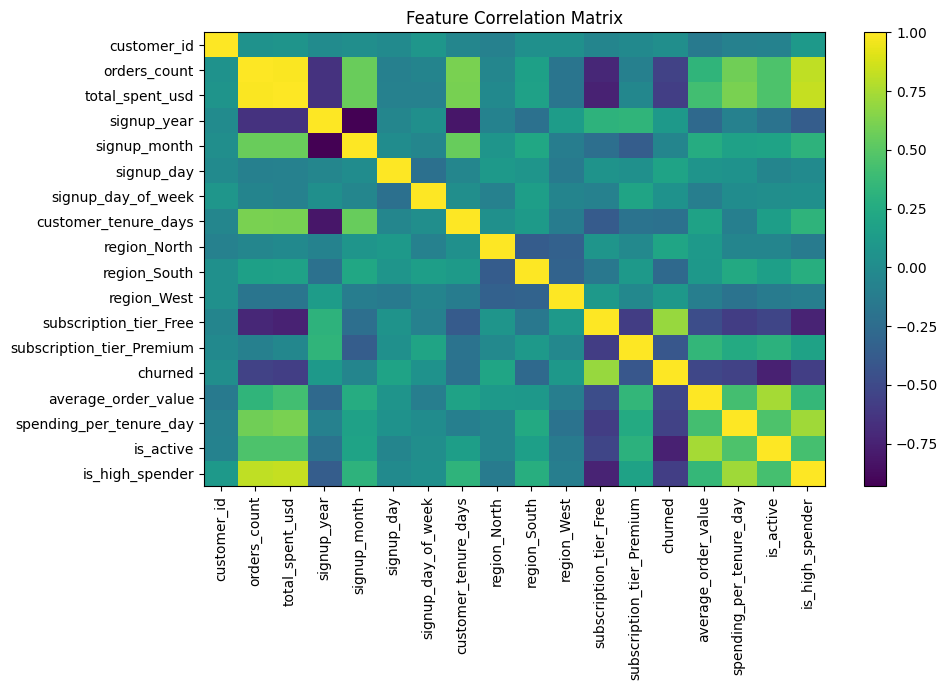

In [364]:
# Plot the correlation matrix

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

## 12.12 Feature Engineering vs Data Preprocessing

Data Preprocessing and Feature Engineering are related,
but they are not exactly the same.

### Data Preprocessing

The main goal is to clean and transform raw data.

Examples:

- Handling missing values
- Removing duplicates
- Encoding categories
- Scaling features

### Feature Engineering

The main goal is to create or transform features
to represent useful information.

Examples:

- Average order value
- Customer tenure
- Spending per day
- Customer activity
- Ratios
- Aggregations

In practice, the two processes often overlap.

The important idea is:

    Preprocessing → Make data usable

    Feature Engineering → Make features more informative

## 12.13 Final Feature Set

After Feature Engineering, our dataset contains both
original and newly created features.

Some examples are:

### Original Features

- `orders_count`
- `total_spent_usd`
- `signup_year`
- `signup_month`
- `signup_day`
- `signup_day_of_week`
- `customer_tenure_days`

### Encoded Features

- `region_*`
- `subscription_tier_*`

### Engineered Features

- `average_order_value`
- `spending_per_tenure_day`
- `is_active`
- `is_high_spender`

Before training a model, we should carefully decide which
features should actually be included.

We should also make sure that no feature contains information
from the future that would not have been available when the
prediction was made.

This is another important aspect of avoiding **Data Leakage**.

## 12.14 Feature Engineering Observation

In this section, we learned how to create new features
from existing data.

We created:

- `average_order_value`
- `spending_per_tenure_day`
- `is_active`
- `is_high_spender`

We also examined feature correlation.

The key lesson is:

    Better features can help a Machine Learning model
    learn useful patterns more effectively.

However, feature engineering should be performed carefully.

We should avoid:

- Irrelevant features
- Redundant features
- Features based on future information
- Features that cause data leakage

Our next step is one of the most important stages
in the Machine Learning workflow:

    Train-Test Split

# 13. Train-Test Split

Train-Test Split is the process of dividing the available
dataset into separate training and testing datasets.

The training dataset is used to:

- Learn patterns
- Train the Machine Learning model

The testing dataset is used to:

- Evaluate the trained model
- Estimate how well it performs on unseen data

A common split is:

    80% → Training Data
    20% → Testing Data

The basic workflow is:

    Complete Dataset
           ↓
      Train-Test Split
        ↙          ↘
    Training       Testing
       ↓              ↓
    Model Training   Final Evaluation

The test data should remain unseen during model training.

This helps us estimate how the model will perform on
new, unseen customers.

## 13.1 Why Do We Need Train-Test Split?

Suppose we train and evaluate a model using exactly
the same data.

The model has already seen those observations.

Therefore, a high accuracy on that same dataset does not
necessarily mean that the model will perform well on
new customers.

This is similar to giving a student the exact questions
that will appear in an exam before the exam.

The student may memorize the answers without actually
understanding the concepts.

Similarly, a Machine Learning model can memorize patterns
in the training data.

Train-Test Split helps us evaluate generalization.

Generalization means:

    The ability of a model to perform well on unseen data.

In [391]:
# Separate features and target

X = feature_df.drop("churned", axis=1)
y = feature_df["churned"]
# Remove identifier columns
# These columns should not be used for prediction
identifier_columns = [
"customer_id",
"name"
]
X = X.drop(
columns=[
column for column in identifier_columns
if column in X.columns
]
)
# Check the feature columns
print("Features:")
print(X.columns.tolist())

Features:
['orders_count', 'total_spent_usd', 'signup_year', 'signup_month', 'signup_day', 'signup_day_of_week', 'customer_tenure_days', 'region_North', 'region_South', 'region_West', 'subscription_tier_Free', 'subscription_tier_Premium', 'average_order_value', 'spending_per_tenure_day', 'is_active', 'is_high_spender']


In [392]:
# Check for non-numerical columns
non_numeric_columns = X.select_dtypes(
exclude=np.number
).columns.tolist()
print("Non-numerical columns:")
print(non_numeric_columns)

Non-numerical columns:
[]


In [394]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)
# Display the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (40, 16)
X_test : (10, 16)
y_train: (40,)
y_test : (10,)


## 13.3 Understanding `test_size`

The parameter:

    test_size=0.20

means that 20% of the observations are placed into
the testing dataset.

Therefore:

    80% → Training
    20% → Testing

For a larger dataset, an 80/20 split is a common starting point.

Other possible splits include:

    70/30
    75/25
    80/20
    90/10

The appropriate split depends on the size of the dataset
and the Machine Learning problem.

## 13.4 Understanding `random_state`

The `train_test_split()` function randomly divides
the dataset.

Therefore, every execution could produce a different split.

We can use:

    random_state=42

to make the split reproducible.

The number `42` is not special.

Any fixed integer can be used.

For example:

    random_state=0
    random_state=42
    random_state=100

The important point is that we use the same value when
we want reproducible results.

## 13.5 Understanding `stratify`

When splitting a classification dataset, we want the training
and testing datasets to have a similar proportion of each class.

For example, suppose our target contains:

    0 → Not Churned
    1 → Churned

If the original dataset contains:

    80% → 0
    20% → 1

we generally want both the training and testing datasets to
maintain approximately the same proportion.

The parameter:

    stratify=y

helps maintain the class distribution during the split.

This is especially useful for classification problems.

In [395]:
# Check the class distribution in the original target

print("Original class distribution:")
print(y.value_counts(normalize=True))

Original class distribution:
churned
0    0.72
1    0.28
Name: proportion, dtype: float64


## 13.6 Checking Class Distribution After the Split

Now we will compare the target distribution in:

- Original dataset
- Training dataset
- Testing dataset

Because we used:

    stratify=y

the class proportions should remain approximately similar.

In [396]:
# Check class distribution in the training set

print("Training class distribution:")
print(y_train.value_counts(normalize=True))

Training class distribution:
churned
0    0.725
1    0.275
Name: proportion, dtype: float64


In [397]:
# Check class distribution in the testing set

print("Testing class distribution:")
print(y_test.value_counts(normalize=True))

Testing class distribution:
churned
0    0.7
1    0.3
Name: proportion, dtype: float64


## 13.7 Comparing Dataset Sizes

We can verify the number of observations present in each
dataset.

Our split uses:

    80% → Training data
    20% → Testing data

The total number of training and testing observations should
be equal to the number of observations in the original dataset.

In [398]:
# Compare the number of observations

print("Total observations :", len(X))
print("Training observations:", len(X_train))
print("Testing observations :", len(X_test))

print(
    "Train + Test:",
    len(X_train) + len(X_test)
)

Total observations : 50
Training observations: 40
Testing observations : 10
Train + Test: 50


## 13.8 Checking the Training Features

The training feature matrix contains the observations that will
be used to train our Machine Learning models.

We will display the first few rows to verify the data.

In [399]:
# Display the training features

X_train.head()

,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,average_order_value,spending_per_tenure_day,is_active,is_high_spender
21,15.0,480.2,2025,10,29,2,244,0,1,0,0,1,32.013333,1.968033,1,0
18,0.0,0.0,2025,12,14,6,198,0,1,0,1,0,0.000000,0.000000,0,0
13,38.0,1120.0,2025,11,4,1,238,0,0,1,0,0,29.473684,4.705882,1,1
49,4.0,88.0,2026,2,7,5,143,0,1,0,1,0,22.000000,0.615385,1,0
44,3.0,68.2,2026,6,5,4,25,1,0,0,1,0,22.733333,2.728000,1,0


## 13.9 Checking the Testing Features

The testing feature matrix contains observations that the model
has not seen during training.

These observations will later be used to evaluate the model.

In [400]:
# Display the testing features

X_test.head()

,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,average_order_value,spending_per_tenure_day,is_active,is_high_spender
19,44.0,1345.8,2026,4,18,5,73,0,0,0,0,0,30.586364,18.435616,1,1
9,8.0,280.6,2026,6,1,0,29,1,0,0,0,1,35.075000,9.675862,1,0
42,0.0,0.0,2026,4,14,1,77,0,0,0,1,0,0.000000,0.000000,0,0
28,19.0,625.3,2026,4,28,1,63,1,0,0,0,1,32.910526,9.925397,1,1
25,22.0,745.6,2026,3,15,6,107,0,1,0,0,1,33.890909,6.968224,1,1


## 13.10 Checking the Training Target

The training target contains the correct output values
corresponding to `X_train`.

For our customer churn problem:

    0 → Customer did not churn
    1 → Customer churned

In [401]:
# Display the training target

y_train.head()

21    0
18    1
13    0
49    0
44    1
Name: churned, dtype: int64

## 13.11 Checking the Testing Target

The testing target contains the correct output values
corresponding to `X_test`.

The model will later make predictions for `X_test`, and those
predictions will be compared with `y_test`.

In [402]:
# Display the testing target

y_test.head()

19    0
9     0
42    1
28    0
25    0
Name: churned, dtype: int64

## 13.12 Train-Test Split Observation

We have now divided our dataset into training and testing sets.

We used:

    test_size=0.20
    random_state=42
    stratify=y

Therefore:

- 80% of the data is used for training.
- 20% of the data is used for testing.
- `random_state=42` makes the split reproducible.
- `stratify=y` helps preserve the class distribution.

The training data will be used to build our Machine Learning
models, while the testing data will be kept for evaluation.

In the next section, we will learn about **Feature Scaling**.

## 14.1 Why Feature Scaling?

Different features can have very different ranges.

For example:

    Age          → 18 to 80
    MonthlyBill  → 20 to 500
    Tenure       → 1 to 72

A Machine Learning algorithm may give more importance to a
feature simply because its numerical values are larger.

Feature Scaling brings numerical features to a comparable scale.

It is particularly important for algorithms such as:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- K-Means Clustering
- Neural Networks

In this notebook, we will use `StandardScaler`.

In [403]:
# Import StandardScaler from scikit-learn

from sklearn.preprocessing import StandardScaler

In [404]:
# Create a StandardScaler object

scaler = StandardScaler()

## 14.4 Fit the Scaler on Training Data

We should fit the scaler only on the training data.

The scaler learns:

- Mean of each feature
- Standard deviation of each feature

We must NOT fit the scaler using the testing data because that
would allow information from the test set to influence the
training process.

This is called **data leakage**.

In [405]:
# Learn the mean and standard deviation from training data

scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 14.5 Transform the Training Data

After fitting the scaler, we can transform the training data.

Standardization uses the formula:

    z = (x - μ) / σ

where:

    x  = original value
    μ  = mean of the feature
    σ  = standard deviation of the feature

After standardization, each feature will generally have:

    Mean ≈ 0
    Standard deviation ≈ 1

In [406]:
# Transform the training data

X_train_scaled = scaler.transform(X_train)

## 14.6 Transform the Testing Data

We use the SAME scaler that was fitted on the training data.

We do not call `fit()` again on the testing data.

We only call `transform()`.

In [407]:
# Transform the testing data using the already fitted scaler

X_test_scaled = scaler.transform(X_test)

## 14.7 Convert Scaled Data to DataFrame

`StandardScaler` returns a NumPy array.

We will convert the scaled data back into DataFrames so that
we can easily inspect the feature names and values.

In [408]:
# Convert scaled training data back to a DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

# Convert scaled testing data back to a DataFrame

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [409]:
# Display the first five rows of scaled training data

X_train_scaled.head()

,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,average_order_value,spending_per_tenure_day,is_active,is_high_spender
21,-0.231385,-0.196389,-1.362770,1.032696,1.458835,-0.563436,1.349914,-0.654654,1.623688,-0.538816,-0.904534,1.623688,0.368414,-0.516833,0.420084,-0.904534
18,-0.981822,-0.992611,-1.362770,1.527400,-0.118284,1.690309,0.706765,-0.654654,1.623688,-0.538816,1.105542,-0.615882,-1.594471,-0.978431,-2.380476,-0.904534
13,0.919285,0.864467,-1.362770,1.280048,-1.169697,-1.126872,1.266025,-0.654654,-0.615882,1.855921,-0.904534,-0.615882,0.212696,0.125325,0.420084,1.105542
49,-0.781705,-0.846698,0.733799,-0.946122,-0.854273,1.126872,-0.062218,-0.654654,1.623688,-0.538816,1.105542,-0.615882,-0.245550,-0.834093,0.420084,-0.904534
44,-0.831734,-0.879528,0.733799,0.043287,-1.064555,0.563436,-1.712035,1.527525,-0.615882,-0.538816,1.105542,-0.615882,-0.200586,-0.338584,0.420084,-0.904534


In [410]:
# Display the first five rows of scaled testing data

X_test_scaled.head()

,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,average_order_value,spending_per_tenure_day,is_active,is_high_spender
19,1.219460,1.238867,0.733799,-0.451418,0.302281,1.126872,-1.040923,-0.654654,-0.615882,-0.538816,-0.904534,-0.615882,0.280919,3.345606,0.420084,1.105542
9,-0.581589,-0.527347,0.733799,0.043287,-1.485120,-1.690309,-1.656109,1.527525,-0.615882,-0.538816,-0.904534,1.623688,0.556138,1.291023,0.420084,-0.904534
42,-0.981822,-0.992611,0.733799,-0.451418,-0.118284,-1.126872,-0.984997,-0.654654,-0.615882,-0.538816,1.105542,-0.615882,-1.594471,-0.978431,-2.380476,-0.904534
28,-0.031268,0.044202,0.733799,-0.451418,1.353694,-1.126872,-1.180738,1.527525,-0.615882,-0.538816,-0.904534,1.623688,0.423425,1.349551,0.420084,1.105542
25,0.118819,0.243672,0.733799,-0.698770,-0.013143,1.690309,-0.565552,-0.654654,1.623688,-0.538816,-0.904534,1.623688,0.483536,0.655952,0.420084,1.105542


## 14.10 Checking the Mean After Scaling

The numerical features in the training dataset should now have
a mean approximately equal to 0.

In [411]:
# Check the mean of each scaled training feature

X_train_scaled.mean()

orders_count                -1.665335e-17
total_spent_usd              1.665335e-17
signup_year                 -1.907030e-13
signup_month                -7.494005e-17
signup_day                  -1.110223e-17
signup_day_of_week           3.330669e-17
customer_tenure_days         1.332268e-16
region_North                -2.220446e-17
region_South                -1.665335e-17
region_West                 -6.661338e-17
subscription_tier_Free       1.110223e-17
subscription_tier_Premium   -3.330669e-17
average_order_value          1.332268e-16
spending_per_tenure_day     -1.332268e-16
is_active                    1.110223e-16
is_high_spender              2.220446e-17
dtype: float64

In [412]:
# Check the standard deviation of each scaled training feature

X_train_scaled.std()

orders_count                 1.012739
total_spent_usd              1.012739
signup_year                  1.012739
signup_month                 1.012739
signup_day                   1.012739
signup_day_of_week           1.012739
customer_tenure_days         1.012739
region_North                 1.012739
region_South                 1.012739
region_West                  1.012739
subscription_tier_Free       1.012739
subscription_tier_Premium    1.012739
average_order_value          1.012739
spending_per_tenure_day      1.012739
is_active                    1.012739
is_high_spender              1.012739
dtype: float64

## 14.12 Final Preprocessing Check

Our data preprocessing pipeline is now ready.

We have:

1. Loaded the dataset.
2. Inspected the data.
3. Handled missing values.
4. Encoded categorical variables.
5. Separated features and target.
6. Split the data into training and testing sets.
7. Used `random_state` for reproducibility.
8. Used `stratify` to preserve class distribution.
9. Fitted `StandardScaler` on training data.
10. Transformed both training and testing data.

The final datasets are:

    X_train_scaled → Training features
    X_test_scaled  → Testing features
    y_train        → Training target
    y_test         → Testing target

These datasets can now be used for Machine Learning models.

In [413]:
# Check the final shapes

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

X_train_scaled: (40, 16)
X_test_scaled : (10, 16)
y_train       : (40,)
y_test        : (10,)


## 14.14 Important Note — Avoiding Data Leakage

Data leakage occurs when information from outside the training
data is used while training a Machine Learning model.

For feature scaling, we must follow this order:

    1. Split the data
    2. Fit the scaler on X_train
    3. Transform X_train
    4. Transform X_test using the same scaler

Correct:

    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

Incorrect:

    scaler.fit(X_test)

or:

    scaler.fit(pd.concat([X_train, X_test]))

The testing data should remain unseen during the training
process.

This helps us obtain a more reliable evaluation of the model.

## 14.15 Training vs Testing Data

It is important to understand the role of each dataset.

### Training Data

Used by the Machine Learning algorithm to learn patterns.

    X_train_scaled → Input features
    y_train        → Correct target values

### Testing Data

Used after training to evaluate how well the model performs on
unseen observations.

    X_test_scaled → Unseen input features
    y_test        → Actual target values

In [414]:
# Display the final training and testing datasets

print("Training Features:")
print(X_train_scaled.shape)

print("\nTesting Features:")
print(X_test_scaled.shape)

print("\nTraining Target:")
print(y_train.shape)

print("\nTesting Target:")
print(y_test.shape)

Training Features:
(40, 16)

Testing Features:
(10, 16)

Training Target:
(40,)

Testing Target:
(10,)


## 14.17 Saving the Scaler

The scaler is part of our preprocessing pipeline.

When we later use the trained model on new customer data,
the new data must be transformed using the SAME scaler.

We can save the scaler using `joblib`.

In [415]:
# Import joblib

import joblib
# Save the fitted scaler

joblib.dump(scaler, "scaler.pkl")
# Load the saved scaler

loaded_scaler = joblib.load("scaler.pkl")
# Check that the scaler was loaded successfully

print(loaded_scaler)

StandardScaler()


## 14.19 Feature Scaling — Summary

Feature scaling makes numerical features comparable in magnitude.

In this notebook we used:

    StandardScaler

The standardization formula is:

    z = (x - μ) / σ

Important rules:

- Fit the scaler only on training data.
- Transform training data using the fitted scaler.
- Transform testing data using the same scaler.
- Never fit the scaler using testing data.
- Avoid data leakage.

Our final data is now ready for Machine Learning model training.

    X_train_scaled
    X_test_scaled
    y_train
    y_test

# 15. End-to-End Preprocessing Pipeline

We will now review the complete preprocessing workflow.

The general workflow is:

    Raw Dataset
          ↓
    Data Inspection
          ↓
    Handle Missing Values
          ↓
    Encode Categorical Features
          ↓
    Separate X and y
          ↓
    Train-Test Split
          ↓
    Feature Scaling
          ↓
    Final Training/Test Data
          ↓
    Machine Learning Model

In [417]:
# Check that all important variables are available

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

X_train_scaled: (40, 16)
X_test_scaled : (10, 16)
y_train       : (40,)
y_test        : (10,)


In [418]:
# Preview the final training data

X_train_scaled.head()

,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,average_order_value,spending_per_tenure_day,is_active,is_high_spender
21,-0.231385,-0.196389,-1.362770,1.032696,1.458835,-0.563436,1.349914,-0.654654,1.623688,-0.538816,-0.904534,1.623688,0.368414,-0.516833,0.420084,-0.904534
18,-0.981822,-0.992611,-1.362770,1.527400,-0.118284,1.690309,0.706765,-0.654654,1.623688,-0.538816,1.105542,-0.615882,-1.594471,-0.978431,-2.380476,-0.904534
13,0.919285,0.864467,-1.362770,1.280048,-1.169697,-1.126872,1.266025,-0.654654,-0.615882,1.855921,-0.904534,-0.615882,0.212696,0.125325,0.420084,1.105542
49,-0.781705,-0.846698,0.733799,-0.946122,-0.854273,1.126872,-0.062218,-0.654654,1.623688,-0.538816,1.105542,-0.615882,-0.245550,-0.834093,0.420084,-0.904534
44,-0.831734,-0.879528,0.733799,0.043287,-1.064555,0.563436,-1.712035,1.527525,-0.615882,-0.538816,1.105542,-0.615882,-0.200586,-0.338584,0.420084,-0.904534


In [419]:
# Preview the target values

y_train.head()

21    0
18    1
13    0
49    0
44    1
Name: churned, dtype: int64

## 15.3 Final Observation

The preprocessing stage is complete.

We now have clean, encoded, split, and scaled data that can be
passed to Machine Learning algorithms.

The next step is **Model Training**.

We will start with:

    Logistic Regression

and learn how to:

- Create a model
- Train the model
- Make predictions
- Evaluate predictions
- Calculate accuracy
- Generate a confusion matrix
- Understand classification metrics

# 16. Logistic Regression

Logistic Regression is a supervised Machine Learning algorithm
used mainly for classification problems.

It predicts the probability that an observation belongs to a
particular class.

For binary classification:

    Class 0 → No
    Class 1 → Yes

In our customer churn problem:

    0 → Customer does not churn
    1 → Customer churns

The model first calculates a probability and then converts that
probability into a class prediction.

In [420]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

## 16.3 Creating the Logistic Regression Model

We first create a Logistic Regression model.

At this stage, the model has not learned anything from our data.

Training will happen using the `.fit()` method.

In [421]:
# Create the Logistic Regression model

logistic_model = LogisticRegression(
    random_state=42
)

## 16.4 Training the Model

We train the model using:

    X_train_scaled
    y_train

The model learns the relationship between the input features
and the target variable.

In [422]:
# Train the Logistic Regression model

logistic_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 16.5 Making Predictions

After training, we can use the model to predict the target
values for unseen testing data.

We use:

    X_test_scaled

The model returns the predicted class for each observation.

In [423]:
# Make predictions on the testing data

y_pred = logistic_model.predict(X_test_scaled)

# Display the first few predictions

y_pred[:10]

array([0, 0, 1, 0, 0, 1, 1, 1, 0, 0])

## 16.6 Comparing Actual and Predicted Values

We can compare:

    y_test → Actual values
    y_pred → Predicted values

This helps us understand whether the model is making correct
predictions.

In [424]:
# Create a comparison DataFrame

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

# Display the first few predictions

comparison.head(10)

,Actual,Predicted
19,0,0
9,0,0
42,1,1
28,0,0
25,0,0
8,1,1
46,1,1
39,0,1
35,0,0
10,0,0


## 16.7 Model Accuracy

Accuracy measures the percentage of predictions that are
correct.

Formula:

    Accuracy = Correct Predictions / Total Predictions

In [425]:
# Import accuracy_score

from sklearn.metrics import accuracy_score

In [426]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9


In [427]:
# Display accuracy as a percentage

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 90.00%


## 16.8 Confusion Matrix

A confusion matrix shows how many predictions were:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

For our churn problem:

    True Positive
    → Model predicted churn and customer actually churned

    True Negative
    → Model predicted no churn and customer actually did not churn

    False Positive
    → Model predicted churn but customer did not churn

    False Negative
    → Model predicted no churn but customer actually churned

In [428]:
# Import confusion_matrix

from sklearn.metrics import confusion_matrix

In [429]:
# Calculate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6 1]
 [0 3]]


In [430]:
# Import matplotlib

import matplotlib.pyplot as plt

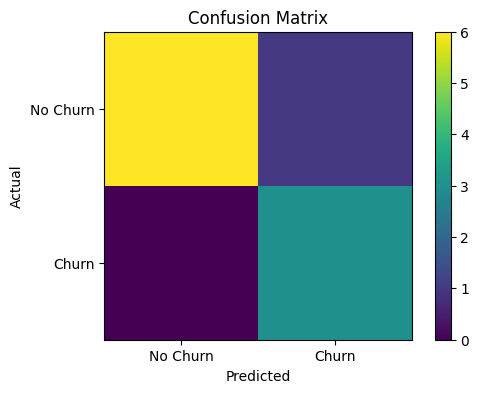

In [431]:
# Display the confusion matrix

plt.figure(figsize=(6, 4))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

plt.colorbar()

plt.show()

## 16.10 Classification Report

Accuracy alone does not always give us a complete picture.

For classification problems, we can also calculate:

- Precision
- Recall
- F1-score

The `classification_report()` function provides these metrics
together.

In [432]:
# Import classification_report

from sklearn.metrics import classification_report

In [433]:
# Generate the classification report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.75      1.00      0.86         3

    accuracy                           0.90        10
   macro avg       0.88      0.93      0.89        10
weighted avg       0.93      0.90      0.90        10



## 16.11 Complete Logistic Regression Workflow

Our first Machine Learning workflow is now:

    Preprocessed Data
           ↓
    Train-Test Split
           ↓
    Feature Scaling
           ↓
    Create Model
           ↓
    Train Model
           ↓
    Make Predictions
           ↓
    Evaluate Model

For Logistic Regression:

    X_train_scaled → Model Training
    y_train        → Model Training

    X_test_scaled  → Predictions
    y_test         → Evaluation

## 16.12 Saving the Trained Model

After training a model, we can save it to a file.

This allows us to reuse the trained model later without
training it again.

In [434]:
# Save the trained Logistic Regression model

joblib.dump(
    logistic_model,
    "logistic_regression_model.pkl"
)

['logistic_regression_model.pkl']

In [435]:
# Load the saved model

loaded_model = joblib.load(
    "logistic_regression_model.pkl"
)

In [436]:
# Verify that the loaded model can make predictions

loaded_predictions = loaded_model.predict(X_test_scaled)

print(loaded_predictions[:10])

[0 0 1 0 0 1 1 1 0 0]


## 16.14 Final Observation

We successfully trained our first classification model.

We learned how to:

- Create a Logistic Regression model
- Train the model using `.fit()`
- Generate predictions using `.predict()`
- Calculate accuracy
- Create a confusion matrix
- Generate a classification report
- Save the trained model
- Load the trained model

The next important step is to understand **how Logistic Regression
actually works mathematically**, including:

    Linear Equation
          ↓
    Sigmoid Function
          ↓
    Probability
          ↓
    Classification

After that, we will move to other classification algorithms.

# 17. Decision Tree

A Decision Tree is a supervised Machine Learning algorithm that
can be used for both classification and regression.

For classification, the tree makes decisions by asking a series
of questions about the input features.

For example:

    Is tenure > 24?
          |
        Yes
          ↓
    Is monthly charge > 70?
       /          \
     Yes           No
      ↓             ↓
   Churn          No Churn

The final node gives the predicted class.

In this notebook, we will use Decision Tree for our customer
churn classification problem.

In [437]:
# Import DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

## 17.3 Creating the Decision Tree Model

We will create a `DecisionTreeClassifier`.

`random_state=42` is used so that the result is reproducible.

In [438]:
# Create the Decision Tree model

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

## 17.4 Training the Decision Tree

The model learns patterns from:

    X_train_scaled
    y_train

Although Decision Trees do not require feature scaling, we can
still use the already prepared training data in this workflow.

The important point is that the training and testing features
must have the same structure.

In [439]:
# Train the Decision Tree model

decision_tree_model.fit(
    X_train_scaled,
    y_train
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## 17.5 Making Predictions

After training, we use the testing dataset to make predictions.

The model has not seen these observations during training.

In [440]:
# Make predictions on the testing data

y_pred_tree = decision_tree_model.predict(
    X_test_scaled
)

# Display the first 10 predictions

y_pred_tree[:10]

array([0, 0, 1, 0, 0, 1, 0, 1, 0, 0])

## 17.6 Evaluating the Decision Tree

We will first calculate the accuracy of the Decision Tree.

In [441]:
# Calculate Decision Tree accuracy

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print(f"Decision Tree Accuracy: {tree_accuracy * 100:.2f}%")

Decision Tree Accuracy: 80.00%


## 17.7 Confusion Matrix

The confusion matrix shows the number of:

- True Negatives
- False Positives
- False Negatives
- True Positives

In [442]:
# Calculate the confusion matrix

tree_cm = confusion_matrix(
    y_test,
    y_pred_tree
)

print(tree_cm)

[[6 1]
 [1 2]]


## 17.8 Classification Report

We will use the classification report to examine:

- Precision
- Recall
- F1-score
- Support

In [443]:
# Display the classification report

print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.67      0.67      0.67         3

    accuracy                           0.80        10
   macro avg       0.76      0.76      0.76        10
weighted avg       0.80      0.80      0.80        10



## 17.9 Feature Importance

One useful property of a Decision Tree is that it can estimate
the importance of each feature.

`feature_importances_` gives the importance assigned to each
feature by the trained tree.

In [444]:
# Get feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": decision_tree_model.feature_importances_
})

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the feature importance

feature_importance

,Feature,Importance
1,total_spent_usd,0.670100
5,signup_day_of_week,0.208986
12,average_order_value,0.120914
2,signup_year,0.000000
3,signup_month,0.000000
4,signup_day,0.000000
6,customer_tenure_days,0.000000
0,orders_count,0.000000
7,region_North,0.000000
8,region_South,0.000000


## 17.10 Visualizing Feature Importance

A bar chart makes it easier to identify which features were most
important to the Decision Tree.

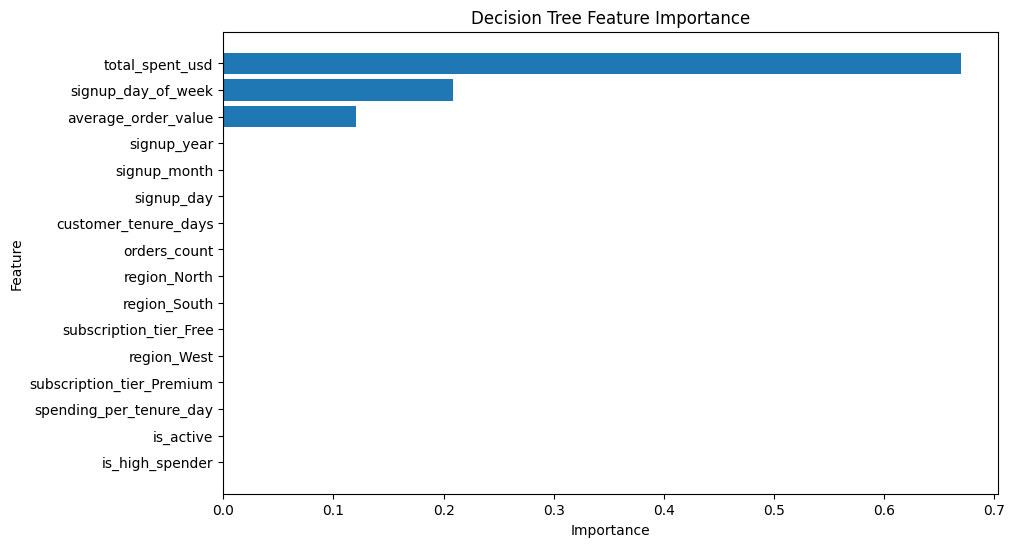

In [445]:
# Plot feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## 17.11 Saving the Decision Tree Model

We can save the trained model using `joblib`.

This allows us to reuse the trained model later.

In [446]:
# Save the trained Decision Tree model

joblib.dump(
    decision_tree_model,
    "decision_tree_model.pkl"
)

['decision_tree_model.pkl']

In [447]:
# Load the saved Decision Tree model

loaded_tree_model = joblib.load(
    "decision_tree_model.pkl"
)

In [448]:
# Verify the loaded model

loaded_tree_predictions = loaded_tree_model.predict(
    X_test_scaled
)

print(loaded_tree_predictions[:10])

[0 0 1 0 0 1 0 1 0 0]


## 17.13 Comparing Models

We already trained Logistic Regression.

Now we can compare its accuracy with the Decision Tree.

This is the beginning of **model comparison**, which is an
important part of the Machine Learning workflow.

In [449]:
# Compare the two models

print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")
print(f"Decision Tree Accuracy      : {tree_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 90.00%
Decision Tree Accuracy      : 80.00%


## 17.14 Observation

We have successfully trained and evaluated a Decision Tree
classifier.

The workflow was:

    Create Model
         ↓
    Train Model
         ↓
    Make Predictions
         ↓
    Calculate Accuracy
         ↓
    Confusion Matrix
         ↓
    Classification Report
         ↓
    Feature Importance
         ↓
    Save Model

We also compared the Decision Tree with Logistic Regression.

Next, we will learn **Random Forest**, which combines multiple
Decision Trees to create a stronger ensemble model.

# 18. Random Forest

Random Forest is an ensemble Machine Learning algorithm.

It combines multiple Decision Trees and combines their predictions
to produce the final prediction.

For classification:

    Multiple Decision Trees
             ↓
       Individual Predictions
             ↓
        Majority Voting
             ↓
       Final Prediction

Random Forest can usually provide better generalization than a
single Decision Tree and is less prone to overfitting.

In [450]:
# Import RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier

## 18.3 Creating the Random Forest Model

We will create a Random Forest classifier.

`n_estimators` specifies the number of Decision Trees in the
forest.

Here we will use 100 trees.

In [451]:
# Create the Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

## 18.4 Training the Random Forest

The model learns patterns from the training data.

We use:

    X_train_scaled
    y_train

In [452]:
# Train the Random Forest model

random_forest_model.fit(
    X_train_scaled,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 18.5 Making Predictions

After training, we use the testing data to make predictions.

The testing data was not used during training.

In [453]:
# Make predictions

y_pred_rf = random_forest_model.predict(
    X_test_scaled
)

# Display the first 10 predictions

y_pred_rf[:10]

array([0, 0, 1, 0, 0, 1, 1, 0, 0, 0])

## 18.6 Evaluating the Random Forest

We will first calculate the accuracy of the Random Forest.

In [454]:
# Calculate Random Forest accuracy

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy: 100.00%


## 18.7 Confusion Matrix

The confusion matrix allows us to see how the Random Forest
classified the test observations.

In [455]:
# Calculate the confusion matrix

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(rf_cm)

[[7 0]
 [0 3]]


## 18.8 Classification Report

The classification report provides:

- Precision
- Recall
- F1-score
- Support

In [456]:
# Display the classification report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## 18.9 Feature Importance

Random Forest can also calculate the importance of each feature.

This helps us understand which features contributed more to the
model's predictions.

In [457]:
# Create a DataFrame containing feature importance

rf_feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the result

rf_feature_importance

,Feature,Importance
1,total_spent_usd,0.246204
12,average_order_value,0.180944
13,spending_per_tenure_day,0.169100
0,orders_count,0.106105
10,subscription_tier_Free,0.069973
14,is_active,0.039127
6,customer_tenure_days,0.036146
3,signup_month,0.035718
5,signup_day_of_week,0.028843
4,signup_day,0.021904


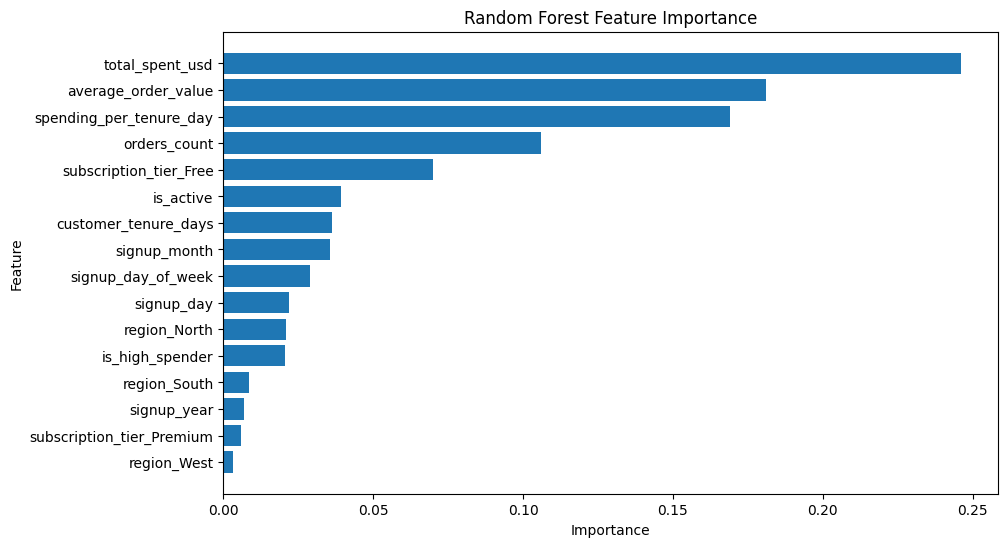

In [458]:
# Plot Random Forest feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    rf_feature_importance["Feature"],
    rf_feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## 18.11 Comparing the Models

We now have three models:

    Logistic Regression
    Decision Tree
    Random Forest

Let's compare their accuracy.

In [459]:
# Compare model accuracy

print(f"Logistic Regression : {accuracy * 100:.2f}%")
print(f"Decision Tree       : {tree_accuracy * 100:.2f}%")
print(f"Random Forest       : {rf_accuracy * 100:.2f}%")

Logistic Regression : 90.00%
Decision Tree       : 80.00%
Random Forest       : 100.00%


In [460]:
# Create a DataFrame for model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        rf_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.9
1,Decision Tree,0.8
2,Random Forest,1.0


## 18.13 Saving the Random Forest Model

We can save the trained model so that it can be reused later
without retraining.

In [461]:
# Save the Random Forest model

joblib.dump(
    random_forest_model,
    "random_forest_model.pkl"
)

['random_forest_model.pkl']

In [462]:
# Load the saved Random Forest model

loaded_rf_model = joblib.load(
    "random_forest_model.pkl"
)

In [463]:
# Verify the loaded model

loaded_rf_predictions = loaded_rf_model.predict(
    X_test_scaled
)

print(loaded_rf_predictions[:10])

[0 0 1 0 0 1 1 0 0 0]


## 18.15 Observation

We have now trained three classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest

For each model, we followed the same Machine Learning workflow:

    Create
       ↓
    Train
       ↓
    Predict
       ↓
    Evaluate
       ↓
    Compare

Random Forest combines multiple Decision Trees instead of
depending on a single tree.

In the next section, we will introduce another classification
algorithm: **K-Nearest Neighbors (KNN)**.

# 19. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised Machine Learning
algorithm used for classification and regression.

For classification, KNN predicts the class of a new observation
by looking at the K closest observations in the training data.

For example, if:

    K = 5

the algorithm finds the 5 nearest data points and uses their
majority class as the prediction.

Basic workflow:

    New Data Point
          ↓
    Find K Nearest Neighbors
          ↓
    Check Their Classes
          ↓
    Majority Voting
          ↓
    Final Prediction

## 19.2 Why Feature Scaling Matters for KNN

KNN uses distance to determine which observations are closest.

If features have very different scales, a feature with larger
values can dominate the distance calculation.

Therefore, feature scaling is important for KNN.

We will use:

    X_train_scaled
    X_test_scaled

In [464]:
# Import KNeighborsClassifier

from sklearn.neighbors import KNeighborsClassifier

## 19.4 Creating the KNN Model

We need to specify the number of neighbors using `n_neighbors`.

Here we start with:

    K = 5

In [465]:
# Create the KNN model

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

## 19.5 Training the KNN Model

KNN is different from some other algorithms because it does not
build a traditional mathematical model during training.

However, in scikit-learn we still use `.fit()` to provide the
training data to the KNN estimator.

In [466]:
# Train the KNN model

knn_model.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## 19.6 Making Predictions

We now use the testing data to predict the target values.

In [467]:
# Make predictions

y_pred_knn = knn_model.predict(
    X_test_scaled
)

# Display the first 10 predictions

y_pred_knn[:10]

array([0, 0, 1, 0, 0, 1, 1, 0, 0, 0])

## 19.7 Evaluating the KNN Model

We will calculate the accuracy of the KNN classifier.

In [468]:
# Calculate KNN accuracy

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

KNN Accuracy: 100.00%


## 19.8 Confusion Matrix

The confusion matrix shows how the KNN model classified the
testing observations.

In [469]:
# Calculate the confusion matrix

knn_cm = confusion_matrix(
    y_test,
    y_pred_knn
)

print(knn_cm)

[[7 0]
 [0 3]]


## 19.9 Classification Report

We can use the classification report to examine the precision,
recall, F1-score, and support of the KNN model.

In [470]:
# Display the classification report

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## 19.10 Experimenting with Different K Values

The value of `K` can affect model performance.

We can test several values of K and compare their accuracy.

For this experiment, we will try:

    K = 3
    K = 5
    K = 7
    K = 9
    K = 11

This helps us understand how the choice of K affects the model.

In [471]:
# Store the K values we want to test

k_values = [3, 5, 7, 9, 11]

# Store the accuracy for each K

knn_results = []

for k in k_values:
    
    # Create the model
    model = KNeighborsClassifier(
        n_neighbors=k
    )
    
    # Train the model
    model.fit(
        X_train_scaled,
        y_train
    )
    
    # Make predictions
    predictions = model.predict(
        X_test_scaled
    )
    
    # Calculate accuracy
    model_accuracy = accuracy_score(
        y_test,
        predictions
    )
    
    # Store the result
    knn_results.append(model_accuracy)

In [472]:
# Create a DataFrame containing K and accuracy

knn_k_results = pd.DataFrame({
    "K": k_values,
    "Accuracy": knn_results
})

knn_k_results

,K,Accuracy
0,3,1.0
1,5,1.0
2,7,1.0
3,9,1.0
4,11,1.0


## 19.12 Finding the Best K

We can identify which tested K value produced the highest
accuracy.

In [473]:
# Find the index of the highest accuracy

best_index = knn_k_results["Accuracy"].idxmax()

# Get the corresponding K value

best_k = knn_k_results.loc[
    best_index,
    "K"
]

# Get the corresponding accuracy

best_knn_accuracy = knn_k_results.loc[
    best_index,
    "Accuracy"
]

print("Best K:", best_k)
print(f"Best Accuracy: {best_knn_accuracy * 100:.2f}%")

Best K: 3
Best Accuracy: 100.00%


## 19.13 Saving the KNN Model

We will save the KNN model so that it can be reused later.

We will use the best K found in our experiment.

In [474]:
# Create the final KNN model using the best K

best_knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

# Train the final KNN model

best_knn_model.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(3)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [475]:
# Save the final KNN model

joblib.dump(
    best_knn_model,
    "knn_model.pkl"
)

['knn_model.pkl']

In [476]:
# Load the saved KNN model

loaded_knn_model = joblib.load(
    "knn_model.pkl"
)

In [477]:
# Verify the loaded model

loaded_knn_predictions = loaded_knn_model.predict(
    X_test_scaled
)

print(loaded_knn_predictions[:10])

[0 0 1 0 0 1 1 0 0 0]


## 19.15 Comparing All Models

We now have four classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. KNN

We can compare their accuracy.

In [478]:
# Create the final model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        rf_accuracy,
        best_knn_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.9
1,Decision Tree,0.8
2,Random Forest,1.0
3,KNN,1.0


## 19.16 Observation

We successfully trained and evaluated K-Nearest Neighbors.

The workflow was:

    Create Model
         ↓
    Train Model
         ↓
    Make Predictions
         ↓
    Evaluate Model
         ↓
    Experiment with K
         ↓
    Select Best K
         ↓
    Save Model

KNN is particularly sensitive to feature scale because it uses
distance to identify neighboring observations.

We also compared KNN with the previously trained models.

Next, we will move to **Support Vector Machine (SVM)**.

# 20. Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised Machine Learning
algorithm used for classification and regression.

For classification, SVM tries to find a decision boundary that
separates different classes.

For our customer churn problem:

    Class 0 → No Churn
    Class 1 → Churn

SVM works especially well when the features are properly scaled.

In this workflow, we will train an SVM classifier and compare
its performance with our previous models.

In [479]:
# Import Support Vector Classifier

from sklearn.svm import SVC

## 20.3 Creating the SVM Model

We will use `SVC` from scikit-learn.

We will keep the default kernel for this first model and use
`random_state=42` for reproducibility.

In [480]:
# Create the SVM model

svm_model = SVC(
    random_state=42
)

## 20.4 Training the SVM

The SVM model learns the relationship between the features and
the target using the training data.

In [481]:
# Train the SVM model

svm_model.fit(
    X_train_scaled,
    y_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## 20.5 Making Predictions

After training, we use the testing data to make predictions.

The model has not seen these observations during training.

In [482]:
# Make predictions

y_pred_svm = svm_model.predict(
    X_test_scaled
)

# Display the first 10 predictions

y_pred_svm[:10]

array([0, 0, 1, 0, 0, 1, 1, 0, 0, 0])

## 20.6 Evaluating the SVM

We will first calculate the accuracy of the SVM classifier.

In [483]:
# Calculate SVM accuracy

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print(f"SVM Accuracy: {svm_accuracy * 100:.2f}%")

SVM Accuracy: 100.00%


## 20.7 Confusion Matrix

The confusion matrix shows the correct and incorrect
classifications made by the SVM.

In [484]:
# Calculate the confusion matrix

svm_cm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(svm_cm)

[[7 0]
 [0 3]]


## 20.8 Classification Report

The classification report provides:

- Precision
- Recall
- F1-score
- Support

In [485]:
# Display the classification report

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## 20.9 Probability Estimates

By default, `SVC` does not provide probability estimates.

If we want to use:

    predict_proba()

we need to create the model with:

    probability=True

This can be useful when we want to examine the predicted
probability for each class.

In [486]:
# Create an SVM model with probability estimates enabled

svm_probability_model = SVC(
    probability=True,
    random_state=42
)

# Train the model

svm_probability_model.fit(
    X_train_scaled,
    y_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [487]:
# Get class probabilities

svm_probabilities = svm_probability_model.predict_proba(
    X_test_scaled
)

# Display the first 5 probability predictions

svm_probabilities[:5]

array([[0.90661243, 0.09338757],
       [0.80986561, 0.19013439],
       [0.00715627, 0.99284373],
       [0.92132438, 0.07867562],
       [0.98467344, 0.01532656]])

## 20.10 Saving the SVM Model

We can save the trained SVM model using `joblib`.

In [488]:
# Save the trained SVM model

joblib.dump(
    svm_model,
    "svm_model.pkl"
)

['svm_model.pkl']

In [489]:
# Load the saved SVM model

loaded_svm_model = joblib.load(
    "svm_model.pkl"
)

In [490]:
# Verify the loaded model

loaded_svm_predictions = loaded_svm_model.predict(
    X_test_scaled
)

print(loaded_svm_predictions[:10])

[0 0 1 0 0 1 1 0 0 0]


## 20.12 Comparing All Classification Models

We now have four classification algorithms:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. KNN

We have now added:

5. Support Vector Machine

Let's compare their accuracy.

In [491]:
# Add SVM to the model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        rf_accuracy,
        best_knn_accuracy,
        svm_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.9
1,Decision Tree,0.8
2,Random Forest,1.0
3,KNN,1.0
4,SVM,1.0


In [492]:
# Sort models from highest to lowest accuracy

model_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Random Forest,1.0
4,SVM,1.0
3,KNN,1.0
0,Logistic Regression,0.9
1,Decision Tree,0.8


## 20.14 Observation

We have now trained five classification models:

    Logistic Regression
    Decision Tree
    Random Forest
    KNN
    SVM

For every model, we followed the same workflow:

    Create Model
         ↓
    Train Model
         ↓
    Make Predictions
         ↓
    Evaluate Model
         ↓
    Compare Results

We should not select a final model using accuracy alone.

In the next section, we will learn how to perform a more
systematic **Model Comparison and Evaluation** using multiple
evaluation metrics and cross-validation.

# 21. Model Comparison & Evaluation

We have trained the following classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)

We will compare their performance using common classification
metrics.

The main metrics are:

- Accuracy
- Precision
- Recall
- F1-score

Accuracy alone may not always be sufficient, especially when
the classes are imbalanced.

In [493]:
# Calculate accuracy for all trained models

model_accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Decision Tree": accuracy_score(y_test, y_pred_tree),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

model_accuracies

{'Logistic Regression': 0.9,
 'Decision Tree': 0.8,
 'Random Forest': 1.0,
 'KNN': 1.0,
 'SVM': 1.0}

In [494]:
# Convert accuracy results into a DataFrame

accuracy_comparison = pd.DataFrame(
    model_accuracies.items(),
    columns=["Model", "Accuracy"]
)

# Sort by accuracy

accuracy_comparison = accuracy_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_comparison

,Model,Accuracy
2,Random Forest,1.0
4,SVM,1.0
3,KNN,1.0
0,Logistic Regression,0.9
1,Decision Tree,0.8


## 21.4 Comparing Multiple Evaluation Metrics

Accuracy gives us the overall percentage of correct predictions.

However, for a classification problem we may also want to know:

### Precision

Of all observations predicted as positive, how many were actually
positive?

### Recall

Of all actual positive observations, how many did the model
correctly identify?

### F1-score

F1-score combines precision and recall into a single metric.

We will calculate these metrics for every model.

In [495]:
# Import precision, recall and F1-score

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [496]:
# Store predictions from all models

model_predictions = {
    "Logistic Regression": y_pred,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm
}

# Calculate evaluation metrics

evaluation_results = []

for model_name, predictions in model_predictions.items():
    
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions)
    })

# Create DataFrame

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9,0.750000,1.000000,0.857143
1,Decision Tree,0.8,0.666667,0.666667,0.666667
2,Random Forest,1.0,1.000000,1.000000,1.000000
3,KNN,1.0,1.000000,1.000000,1.000000
4,SVM,1.0,1.000000,1.000000,1.000000


## 21.6 Comparing Models Using F1-score

For classification problems where both precision and recall are
important, F1-score can be useful for comparing models.

We will sort the models by F1-score.

In [497]:
# Sort models by F1-score

evaluation_df.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,1.0,1.000000,1.000000,1.000000
4,SVM,1.0,1.000000,1.000000,1.000000
3,KNN,1.0,1.000000,1.000000,1.000000
0,Logistic Regression,0.9,0.750000,1.000000,0.857143
1,Decision Tree,0.8,0.666667,0.666667,0.666667


## 21.7 Identifying the Best Model

We can identify the model with the highest F1-score.

This does not automatically mean it is the best model for every
real-world problem.

The final model should be selected based on the problem
requirements and appropriate evaluation metrics.

In [498]:
# Find the model with the highest F1-score

best_model_index = evaluation_df["F1-Score"].idxmax()

best_model_name = evaluation_df.loc[
    best_model_index,
    "Model"
]

best_model_name

'Random Forest'

## 21.8 Training vs Testing Performance

Comparing training and testing performance can help us identify
possible overfitting.

If:

    Training performance is very high
    Testing performance is significantly lower

the model may be overfitting the training data.

We will compare training and testing accuracy for our models.

In [499]:
# Calculate training accuracy for each model

training_accuracies = {
    "Logistic Regression": logistic_model.score(
        X_train_scaled,
        y_train
    ),
    
    "Decision Tree": decision_tree_model.score(
        X_train_scaled,
        y_train
    ),
    
    "Random Forest": random_forest_model.score(
        X_train_scaled,
        y_train
    ),
    
    "KNN": best_knn_model.score(
        X_train_scaled,
        y_train
    ),
    
    "SVM": svm_model.score(
        X_train_scaled,
        y_train
    )
}

In [500]:
# Create a comparison table

train_test_comparison = pd.DataFrame({
    "Model": list(training_accuracies.keys()),
    "Training Accuracy": list(training_accuracies.values()),
    "Testing Accuracy": [
        model_accuracies[model]
        for model in training_accuracies.keys()
    ]
})

train_test_comparison

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,1.000,0.9
1,Decision Tree,1.000,0.8
2,Random Forest,1.000,1.0
3,KNN,0.925,1.0
4,SVM,0.975,1.0


## 21.10 Accuracy Gap

The difference between training and testing accuracy can give us
a basic indication of possible overfitting.

We calculate:

    Accuracy Gap =
    Training Accuracy - Testing Accuracy

In [501]:
# Calculate the training-testing accuracy gap

train_test_comparison["Accuracy Gap"] = (
    train_test_comparison["Training Accuracy"]
    - train_test_comparison["Testing Accuracy"]
)

train_test_comparison

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Logistic Regression,1.000,0.9,0.100
1,Decision Tree,1.000,0.8,0.200
2,Random Forest,1.000,1.0,0.000
3,KNN,0.925,1.0,-0.075
4,SVM,0.975,1.0,-0.025


## 21.11 Final Model Comparison

We have now compared our models using:

- Accuracy
- Precision
- Recall
- F1-score
- Training accuracy
- Testing accuracy
- Accuracy gap

This gives us a much better understanding of model performance
than looking at accuracy alone.

However, our current evaluation is based on a single train-test
split.

A different split could produce slightly different results.

To obtain a more reliable estimate of model performance, we will
next use **Cross-Validation**.

## 21.12 Observation

Model comparison is an important part of the Machine Learning
workflow.

We should not simply choose a model because it has the highest
training accuracy.

Instead, we should consider:

    Performance on unseen data
    Precision
    Recall
    F1-score
    Overfitting
    Problem requirements

Our next step is **Cross-Validation**, which allows us to evaluate
models across multiple training and validation splits.

# 21. Model Comparison & Evaluation

We have trained the following classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)

We will compare their performance using common classification
metrics.

The main metrics are:

- Accuracy
- Precision
- Recall
- F1-score

Accuracy alone may not always be sufficient, especially when
the classes are imbalanced.

# 22. Cross-Validation

Previously, we evaluated our models using one train-test split.

For example:

    80% → Training
    20% → Testing

The result can depend on how the data was split.

Cross-validation evaluates a model using multiple different
training and validation splits.

This gives us a more reliable estimate of model performance.

## 22.2 K-Fold Cross-Validation

In K-Fold Cross-Validation, the dataset is divided into K parts
called folds.

For example, with:

    K = 5

the process is approximately:

    Fold 1 → Validation
    Folds 2-5 → Training

    Fold 2 → Validation
    Folds 1,3-5 → Training

    Fold 3 → Validation
    Other folds → Training

    ...

Each fold is used as the validation set once.

Finally, the scores from all folds are averaged.

In [503]:
# Import cross-validation functions

from sklearn.model_selection import cross_val_score

## 22.4 Logistic Regression Cross-Validation

Let's start by evaluating Logistic Regression using 5-fold
cross-validation.

In [504]:
# Perform 5-fold cross-validation

logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

# Display individual fold scores

print("Fold Scores:", logistic_cv_scores)

# Display average score

print(
    f"Mean Accuracy: {logistic_cv_scores.mean() * 100:.2f}%"
)

Fold Scores: [1.    0.875 1.    0.875 0.875]
Mean Accuracy: 92.50%


## 22.5 Decision Tree Cross-Validation

In [505]:
# Perform 5-fold cross-validation for Decision Tree

tree_cv_scores = cross_val_score(
    decision_tree_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold Scores:", tree_cv_scores)

print(
    f"Mean Accuracy: {tree_cv_scores.mean() * 100:.2f}%"
)

Fold Scores: [0.875 0.75  1.    0.625 0.75 ]
Mean Accuracy: 80.00%


## 22.6 Random Forest Cross-Validation

In [506]:
# Perform 5-fold cross-validation for Random Forest

rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold Scores:", rf_cv_scores)

print(
    f"Mean Accuracy: {rf_cv_scores.mean() * 100:.2f}%"
)

Fold Scores: [0.875 0.75  1.    0.625 0.875]
Mean Accuracy: 82.50%


## 22.7 KNN Cross-Validation

In [507]:
# Perform 5-fold cross-validation for KNN

knn_cv_scores = cross_val_score(
    best_knn_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold Scores:", knn_cv_scores)

print(
    f"Mean Accuracy: {knn_cv_scores.mean() * 100:.2f}%"
)

Fold Scores: [0.875 0.875 1.    0.875 0.875]
Mean Accuracy: 90.00%


## 22.8 SVM Cross-Validation

In [508]:
# Perform 5-fold cross-validation for SVM

svm_cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold Scores:", svm_cv_scores)

print(
    f"Mean Accuracy: {svm_cv_scores.mean() * 100:.2f}%"
)

Fold Scores: [0.875 0.875 1.    0.75  0.875]
Mean Accuracy: 87.50%


## 22.9 Comparing Cross-Validation Results

We can now compare the average 5-fold cross-validation accuracy
of all five models.

In [509]:
# Create a cross-validation comparison table

cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Mean CV Accuracy": [
        logistic_cv_scores.mean(),
        tree_cv_scores.mean(),
        rf_cv_scores.mean(),
        knn_cv_scores.mean(),
        svm_cv_scores.mean()
    ],
    "CV Std": [
        logistic_cv_scores.std(),
        tree_cv_scores.std(),
        rf_cv_scores.std(),
        knn_cv_scores.std(),
        svm_cv_scores.std()
    ]
})

cv_comparison

,Model,Mean CV Accuracy,CV Std
0,Logistic Regression,0.925,0.061237
1,Decision Tree,0.800,0.127475
2,Random Forest,0.825,0.127475
3,KNN,0.900,0.050000
4,SVM,0.875,0.079057


In [510]:
# Sort models by mean cross-validation accuracy

cv_comparison.sort_values(
    by="Mean CV Accuracy",
    ascending=False
)

,Model,Mean CV Accuracy,CV Std
0,Logistic Regression,0.925,0.061237
3,KNN,0.900,0.050000
4,SVM,0.875,0.079057
2,Random Forest,0.825,0.127475
1,Decision Tree,0.800,0.127475


## 22.11 Understanding Cross-Validation Variation

The standard deviation shows how much the model's performance
varied between the different folds.

A smaller standard deviation generally means the model produced
more consistent results across the folds.

Therefore, we can look at both:

    Mean CV Accuracy
    CV Standard Deviation

when comparing models.

## 22.12 Cross-Validation Using F1-score

We can also perform cross-validation using F1-score.

This allows us to compare models based on a metric that considers
both precision and recall.

In [511]:
# Calculate F1-score using cross-validation

logistic_f1_cv = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

tree_f1_cv = cross_val_score(
    decision_tree_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

rf_f1_cv = cross_val_score(
    random_forest_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

knn_f1_cv = cross_val_score(
    best_knn_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

svm_f1_cv = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

In [512]:
# Create F1-score cross-validation comparison

f1_cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Mean CV F1-Score": [
        logistic_f1_cv.mean(),
        tree_f1_cv.mean(),
        rf_f1_cv.mean(),
        knn_f1_cv.mean(),
        svm_f1_cv.mean()
    ]
})

# Sort by F1-score

f1_cv_comparison.sort_values(
    by="Mean CV F1-Score",
    ascending=False
)

,Model,Mean CV F1-Score
0,Logistic Regression,0.826667
3,KNN,0.760000
4,SVM,0.626667
2,Random Forest,0.604762
1,Decision Tree,0.566667


## 22.14 Observation

Cross-validation allows us to evaluate our models across multiple
different validation splits instead of relying on a single split.

We used:

    5-Fold Cross-Validation

We evaluated models using:

    Accuracy
    F1-score

We also examined the standard deviation of the accuracy scores.

Cross-validation gives us a better understanding of how
consistently a model performs.

However, we still have another important step:

**Hyperparameter Tuning**

Instead of manually choosing model parameters, we can search for
better parameter combinations systematically.

Next, we will learn **Grid Search and Hyperparameter Tuning**.

# 23. Hyperparameter Tuning

Hyperparameters are settings that we choose before training a
Machine Learning model.

They are different from model parameters, which are learned
during training.

Examples:

    Random Forest
    → n_estimators
    → max_depth

    KNN
    → n_neighbors

    SVM
    → C
    → kernel
    → gamma

Instead of choosing these values manually, we can search for
better combinations using hyperparameter tuning.

## 23.2 Grid Search

Grid Search tests different combinations of hyperparameters.

For example:

    n_estimators = [50, 100, 200]
    max_depth = [None, 5, 10]

Grid Search evaluates the possible combinations and identifies
the combination that performs best according to the selected
scoring metric.

We will use `GridSearchCV`.

In [513]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

## 23.4 Hyperparameter Tuning — Random Forest

Random Forest has several important hyperparameters.

We will tune:

- `n_estimators` → Number of trees
- `max_depth` → Maximum depth of each tree
- `min_samples_split` → Minimum samples required to split a node

In [514]:
# Create a Random Forest model for tuning

rf_tuning_model = RandomForestClassifier(
    random_state=42
)

In [515]:
# Define the hyperparameter values to test

rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

## 23.6 Creating Grid Search

We will use:

    cv=5

This means each parameter combination will be evaluated using
5-fold cross-validation.

We will use F1-score as the scoring metric.

In [516]:
# Create GridSearchCV

rf_grid_search = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [517]:
# Run the hyperparameter search

rf_grid_search.fit(
    X_train_scaled,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

## 23.8 Best Hyperparameters

After Grid Search finishes, we can see which combination of
hyperparameters produced the best cross-validation score.

In [518]:
# Display the best hyperparameters

print("Best Parameters:")
print(rf_grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [519]:
# Display the best cross-validation F1-score

print(
    f"Best CV F1-Score: "
    f"{rf_grid_search.best_score_:.4f}"
)

Best CV F1-Score: 0.6648


## 23.10 Getting the Best Model

`best_estimator_` contains the Random Forest model trained using
the best hyperparameter combination found by Grid Search.

In [520]:
# Get the best Random Forest model

best_rf_model = rf_grid_search.best_estimator_

In [521]:
# Make predictions using the tuned model

y_pred_best_rf = best_rf_model.predict(
    X_test_scaled
)

In [522]:
# Calculate test accuracy

best_rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

print(
    f"Tuned Random Forest Accuracy: "
    f"{best_rf_accuracy * 100:.2f}%"
)

Tuned Random Forest Accuracy: 100.00%


In [523]:
# Display the classification report

print(
    classification_report(
        y_test,
        y_pred_best_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## 23.13 Before vs After Hyperparameter Tuning

We can compare the original Random Forest with the tuned Random
Forest.

This allows us to see whether hyperparameter tuning improved
performance on the test set.

In [524]:
# Compare original and tuned Random Forest

print(
    f"Original Random Forest Accuracy: "
    f"{rf_accuracy * 100:.2f}%"
)

print(
    f"Tuned Random Forest Accuracy  : "
    f"{best_rf_accuracy * 100:.2f}%"
)

Original Random Forest Accuracy: 100.00%
Tuned Random Forest Accuracy  : 100.00%


## 23.14 Hyperparameter Tuning — KNN

For KNN, `n_neighbors` is an important hyperparameter.

Instead of manually testing K values, we can use Grid Search.

We will test:

    K = 3, 5, 7, 9, 11, 15, 20

In [525]:
# Create a KNN model

knn_tuning_model = KNeighborsClassifier()

In [526]:
# Create a KNN model

knn_tuning_model = KNeighborsClassifier()

In [527]:
# Define the K values to test

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 20]
}

In [528]:
# Create GridSearchCV for KNN

knn_grid_search = GridSearchCV(
    estimator=knn_tuning_model,
    param_grid=knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [529]:
# Run the KNN hyperparameter search

knn_grid_search.fit(
    X_train_scaled,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

In [530]:
# Display the best K

print("Best K:", knn_grid_search.best_params_["n_neighbors"])

print(
    f"Best CV F1-Score: "
    f"{knn_grid_search.best_score_:.4f}"
)

Best K: 3
Best CV F1-Score: 0.7600


In [531]:
# Get the best KNN model

best_knn_tuned_model = knn_grid_search.best_estimator_

In [532]:
# Make predictions

y_pred_best_knn = best_knn_tuned_model.predict(
    X_test_scaled
)

# Calculate accuracy

best_knn_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_best_knn
)

print(
    f"Tuned KNN Accuracy: "
    f"{best_knn_tuned_accuracy * 100:.2f}%"
)

Tuned KNN Accuracy: 100.00%


## 23.18 Final Comparison After Tuning

We can now compare the original and tuned versions of our
models.

The purpose of tuning is not to guarantee a higher test score.
Instead, it helps us systematically search for hyperparameter
values that perform well during cross-validation.

In [533]:
# Compare Random Forest and KNN before and after tuning

tuning_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest",
        "KNN",
        "Tuned KNN"
    ],
    "Test Accuracy": [
        rf_accuracy,
        best_rf_accuracy,
        best_knn_accuracy,
        best_knn_tuned_accuracy
    ]
})

tuning_comparison

,Model,Test Accuracy
0,Random Forest,1.0
1,Tuned Random Forest,1.0
2,KNN,1.0
3,Tuned KNN,1.0


In [534]:
# Save the tuned Random Forest model

joblib.dump(
    best_rf_model,
    "best_random_forest_model.pkl"
)

['best_random_forest_model.pkl']

In [535]:
# Save the tuned KNN model

joblib.dump(
    best_knn_tuned_model,
    "best_knn_model.pkl"
)

['best_knn_model.pkl']

## 23.21 Observation

We have now learned how to perform hyperparameter tuning.

We used:

    GridSearchCV

and combined it with:

    5-Fold Cross-Validation

We tuned:

    Random Forest
    KNN

The workflow is now:

    Model
       ↓
    Cross-Validation
       ↓
    Hyperparameter Search
       ↓
    Best Parameters
       ↓
    Best Model
       ↓
    Test Set Evaluation

Hyperparameter tuning is now complete.

Next, we will select and compare the final models before creating
our complete end-to-end Machine Learning workflow.

# 24. Final Model Selection

We have trained and evaluated multiple classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. KNN
5. SVM

We also performed:

- Accuracy evaluation
- Precision evaluation
- Recall evaluation
- F1-score evaluation
- Training vs testing comparison
- Cross-validation
- Hyperparameter tuning

The goal is now to select a suitable final model.

We should not select a model based only on training accuracy.

The final decision should consider performance on unseen data
and the evaluation metrics relevant to the problem.

In [536]:
# Display the evaluation results

evaluation_df.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,1.0,1.000000,1.000000,1.000000
4,SVM,1.0,1.000000,1.000000,1.000000
3,KNN,1.0,1.000000,1.000000,1.000000
0,Logistic Regression,0.9,0.750000,1.000000,0.857143
1,Decision Tree,0.8,0.666667,0.666667,0.666667


In [537]:
# Display cross-validation results

cv_comparison.sort_values(
    by="Mean CV Accuracy",
    ascending=False
)

,Model,Mean CV Accuracy,CV Std
0,Logistic Regression,0.925,0.061237
3,KNN,0.900,0.050000
4,SVM,0.875,0.079057
2,Random Forest,0.825,0.127475
1,Decision Tree,0.800,0.127475


In [538]:
# Display test accuracy for all models

accuracy_comparison

,Model,Accuracy
2,Random Forest,1.0
4,SVM,1.0
3,KNN,1.0
0,Logistic Regression,0.9
1,Decision Tree,0.8


In [539]:
# Display the tuned model comparison

tuning_comparison

,Model,Test Accuracy
0,Random Forest,1.0
1,Tuned Random Forest,1.0
2,KNN,1.0
3,Tuned KNN,1.0


## 24.6 Selecting the Best Model

For this classification workflow, we will use F1-score as the
primary metric for selecting the best model.

F1-score is useful because it considers both:

    Precision
    Recall

We will first identify the best-performing model from our
evaluation results.

In [540]:
# Find the model with the highest F1-score

best_f1_index = evaluation_df["F1-Score"].idxmax()

best_f1_model_name = evaluation_df.loc[
    best_f1_index,
    "Model"
]

best_f1_score = evaluation_df.loc[
    best_f1_index,
    "F1-Score"
]

print("Best Model:", best_f1_model_name)
print(f"F1-Score: {best_f1_score:.4f}")

Best Model: Random Forest
F1-Score: 1.0000


## 24.7 Selecting the Final Model Object

Now we will connect the selected model name with the actual
trained model object.

This allows us to use the selected model for future predictions.

In [541]:
# Store all trained models

trained_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "KNN": best_knn_model,
    "SVM": svm_model
}

# Select the final model

final_model = trained_models[
    best_f1_model_name
]

print(final_model)

RandomForestClassifier(random_state=42)


In [542]:
# Generate predictions using the final model

final_predictions = final_model.predict(
    X_test_scaled
)

In [543]:
# Calculate final model metrics

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-Score : {final_f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000


In [544]:
# Generate the final confusion matrix

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print(final_cm)

[[7 0]
 [0 3]]


In [545]:
# Display the final classification report

print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## 24.11 Saving the Final Model

We will save the selected model so that it can be reused later.

The model and the scaler are both required when making
predictions on new data.

    Final Model
         +
    Scaler
         ↓
    New Data Prediction

In [546]:
# Save the final selected model

joblib.dump(
    final_model,
    "final_model.pkl"
)

['final_model.pkl']

In [547]:
# Save the name of the final model

print("Final selected model:", best_f1_model_name)

Final selected model: Random Forest


In [548]:
# Load the final model

loaded_final_model = joblib.load(
    "final_model.pkl"
)

In [549]:
# Verify that the loaded model works

loaded_final_predictions = loaded_final_model.predict(
    X_test_scaled
)

print(
    "Predictions:",
    loaded_final_predictions[:10]
)

Predictions: [0 0 1 0 0 1 1 0 0 0]


## 24.14 Final Model Selection Workflow

Our complete model-selection process is:

    Train Multiple Models
             ↓
    Evaluate Models
             ↓
    Cross-Validation
             ↓
    Hyperparameter Tuning
             ↓
    Compare Metrics
             ↓
    Select Final Model
             ↓
    Evaluate on Test Data
             ↓
    Save Final Model

The test set is used only for final evaluation after the model
selection process.

The final model can now be used for predictions on new data.

## 24.15 Observation

We have completed the model selection stage.

We trained multiple classification algorithms and compared their
performance using several evaluation methods.

The final model was selected based on F1-score and then evaluated
on the test dataset.

We also saved:

    final_model.pkl
    scaler.pkl

These files can be used together to make predictions on new
customer data.

The next and final stage of this notebook is to build a
**Complete End-to-End ML Workflow** that puts preprocessing,
training, evaluation, and prediction together.

# Import Pipeline
from sklearn.pipeline import Pipeline

# Create the final ML pipeline
final_pipeline = Pipeline([
    ("scaler", scaler),
    ("model", final_model)
])

# Display the pipeline
final_pipeline

In [551]:
# Import Pipeline
from sklearn.pipeline import Pipeline

# Create the final ML pipeline
final_pipeline = Pipeline([
    ("scaler", scaler),
    ("model", final_model)
])

# Display the pipeline
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [552]:
# Make predictions using the complete pipeline
pipeline_predictions = final_pipeline.predict(X_test)

# Display predictions
pipeline_predictions[:10]

c:\Users\soumy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0, 0, 1, 0, 0, 1, 1, 0, 0, 0])

In [553]:
# Calculate pipeline accuracy
pipeline_accuracy = accuracy_score(
    y_test,
    pipeline_predictions
)

print("Final Pipeline Accuracy:", pipeline_accuracy)

Final Pipeline Accuracy: 1.0


In [554]:
# Compare actual and predicted values
pipeline_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pipeline_predictions
})

pipeline_comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,0,0
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [555]:
# Save the complete pipeline
joblib.dump(
    final_pipeline,
    "final_ml_pipeline.pkl"
)

print("Final ML pipeline saved successfully.")

Final ML pipeline saved successfully.


In [556]:
# Load the saved pipeline
loaded_pipeline = joblib.load(
    "final_ml_pipeline.pkl"
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [557]:
# Make predictions using the loaded pipeline
loaded_predictions = loaded_pipeline.predict(X_test)

# Compare predictions
loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

print("Loaded Pipeline Accuracy:", loaded_accuracy)

Loaded Pipeline Accuracy: 1.0


c:\Users\soumy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [558]:
# Verify that both predictions are identical
print(
    "Predictions identical:",
    np.array_equal(
        pipeline_predictions,
        loaded_predictions
    )
)

Predictions identical: True


In [559]:
# Take one unseen example from the test dataset
new_data = X_test.iloc[[0]]

# Display the new data
new_data

,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,average_order_value,spending_per_tenure_day,is_active,is_high_spender
19,44.0,1345.8,2026,4,18,5,73,0,0,0,0,0,30.586364,18.435616,1,1


In [560]:
# Make prediction using the complete pipeline
new_prediction = loaded_pipeline.predict(new_data)

print("Prediction:", new_prediction[0])

Prediction: 0


c:\Users\soumy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [561]:
def predict_new_data(model_pipeline, new_data):
    """
    Make predictions on new data using the trained pipeline.
    """
    
    # Generate prediction
    prediction = model_pipeline.predict(new_data)
    
    return prediction

In [562]:
# Use the prediction function
prediction = predict_new_data(
    loaded_pipeline,
    new_data
)

print("Predicted Class:", prediction[0])

Predicted Class: 0


c:\Users\soumy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1. Load Dataset
       ↓
2. Understand Dataset
       ↓
3. Clean Data
       ↓
4. Handle Missing Values
       ↓
5. Encode Categorical Data
       ↓
6. Separate Features and Target
       ↓
7. Train-Test Split
       ↓
8. Feature Scaling
       ↓
9. Train Multiple Models
       ↓
10. Make Predictions
       ↓
11. Evaluate Models
       ↓
12. Cross-Validation
       ↓
13. Hyperparameter Tuning
       ↓
14. Select Final Model
       ↓
15. Create Pipeline
       ↓
16. Save Pipeline
       ↓
17. Load Pipeline
       ↓
18. Predict New Data

In [563]:
# Check important final objects

print("Scaler:", type(scaler).__name__)
print("Final Model:", type(final_model).__name__)
print("Pipeline:", type(final_pipeline).__name__)
print("Pipeline Accuracy:", pipeline_accuracy)

Scaler: StandardScaler
Final Model: RandomForestClassifier
Pipeline: Pipeline
Pipeline Accuracy: 1.0
